# Objetivo 1 — Classificação de Attrition
## Estrutura do Notebook
**Parte I — Comparação de Modelos**
- Baseline: Árvore de Decisão
- Candidato 1: Random Forest
- Candidato 2: Gradient Boosting
- Candidato 3: XGBoost
- Candidato 4: LightGBM
- Candidato 5: CatBoost
- Candidato 6: SVM
- Candidato 7: Árvore de Decisão com Pruning
- Candidato 8: Regressão Logística (baseline linear)
- Candidato 9: Linear Discriminant Analysis (LDA)
- Candidato 10: Naive Bayes (GaussianNB)
- Candidato 11: K-Nearest Neighbors (KNN)
- Candidato 12: Extra Trees
- Candidato 13: Rede Neuronal MLP (sklearn)
- Candidato 14: Rede Neuronal TabNet (pytorch-tabnet)
- Candidato 15: Rede Neuronal Keras (TensorFlow)
- Candidato 16: Keras com Dropout + BatchNormalization
- Candidato 17: GANDALF (pytorch-tabular)
- Candidato 18: FT-Transformer (pytorch-tabular)
- Tabela Comparativa Global (todos os modelos)

**Parte II — Modelo Campeão**
- Regressão Logística Otimizada (pipeline completa: split → normalizador → SMOTE → GridSearchCV → threshold)


---
# Parte I — Comparação de Modelos

## 0. INSTALAÇÃO DE BIBLIOTECAS

In [1]:
# Instala as bibliotecas de boosting que não vêm por defeito no ambiente
import subprocess
# Lista das bibliotecas a instalar: XGBoost, LightGBM e CatBoost
libs = ["xgboost", "lightgbm", "catboost"]
# Instala cada biblioteca silenciosamente (-q) e verifica se correu bem
for lib in libs:
    subprocess.run(["pip", "install", lib, "-q"], check=True)
    print(f"  {lib} instalado.")
print("\nInstalação concluída.")

  xgboost instalado.
  lightgbm instalado.
  catboost instalado.

Instalação concluída.


## BASELINE — Árvore de Decisão
Modelo baseline com `DecisionTreeClassifier` (parâmetros default).

In [2]:
# 1. IMPORTAÇÕES

# Bibliotecas de manipulação de dados e cálculo numérico
import pandas as pd
import numpy as np
# Biblioteca de visualização
import matplotlib.pyplot as plt

# Modelo de Árvore de Decisão e função para visualizar a árvore
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Função para dividir os dados em treino/teste
from sklearn.model_selection import train_test_split
# Métricas de avaliação: relatório de classificação, matriz de confusão, F1, AUC-ROC, etc.
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay,
    accuracy_score
)

# Suprime avisos desnecessários durante a execução
import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [3]:
# 2. CARREGAMENTO DO DATASET

# URL do dataset processado no GitHub do projeto
url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
# Carrega o dataset diretamente do GitHub para um DataFrame
df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

Dataset carregado: 1470 linhas, 62 colunas


In [4]:
# 4. DIVISÃO TREINO / TESTE — a partir do dataset completo
# URL do dataset processado no GitHub do projeto
url_full = 'https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv'
df = pd.read_csv(url_full)

# Colunas a remover: variáveis categóricas e o target original (mantemos só Attrition_bin)
cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]
# Colunas a remover: variáveis categóricas e o target original (mantemos só Attrition_bin)
# Filtra apenas as colunas que existem no dataset (evita erro se alguma já tiver sido removida)
cols_remover = [c for c in cols_remover if c in df.columns]
df_model = df.drop(columns=cols_remover)

# Define o nome da variável alvo (0 = ficou, 1 = saiu)
TARGET = "Attrition_bin"
# Separa as features (X) do target (y)
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
# Mantém apenas colunas numéricas (modelos sklearn não aceitam strings)
X = X.select_dtypes(include=[np.number])

# Divide 80% para treino e 20% para teste
# stratify=y garante que a proporção Yes/No é igual nos dois conjuntos
# random_state=42 torna a divisão reprodutível
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Features utilizadas: {X.shape[1]}")
print(f"Treino: {X_train.shape[0]} observacoes  ({y_train.mean()*100:.1f}% Yes)")
print(f"Teste:  {X_test.shape[0]} observacoes  ({y_test.mean()*100:.1f}% Yes)")
# Autor: Figueira, L.

Features utilizadas: 53
Treino: 1176 observacoes  (16.2% Yes)
Teste:  294 observacoes  (16.0% Yes)


In [5]:
# 5. TREINO DO MODELO
# DecisionTreeClassifier() — todos os parâmetros default

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf.get_depth()}")
print(f"  Numero de folhas:       {clf.get_n_leaves()}")

Modelo treinado.
  Profundidade da arvore: 15
  Numero de folhas:       129


In [6]:
# 6. MÉTRICAS NO TREINO

# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf.predict_proba(X_train)[:, 1]

print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [7]:
# 7. MÉTRICAS NO TESTE

# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf.predict_proba(X_test)[:, 1]

print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3273
  Precision: 0.2857
  Recall:    0.3830
  AUC-ROC:   0.6004

              precision    recall  f1-score   support

  Permaneceu       0.87      0.82      0.85       247
        Saiu       0.29      0.38      0.33        47

    accuracy                           0.75       294
   macro avg       0.58      0.60      0.59       294
weighted avg       0.78      0.75      0.76       294



In [8]:
# 8. TABELA COMPARATIVA TREINO vs TESTE

resultados = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)

print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados)

# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.000,1.0000
1,Teste,0.3273,0.2857,0.383,0.6004



  Diferenca F1 (treino - teste): 0.6727
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


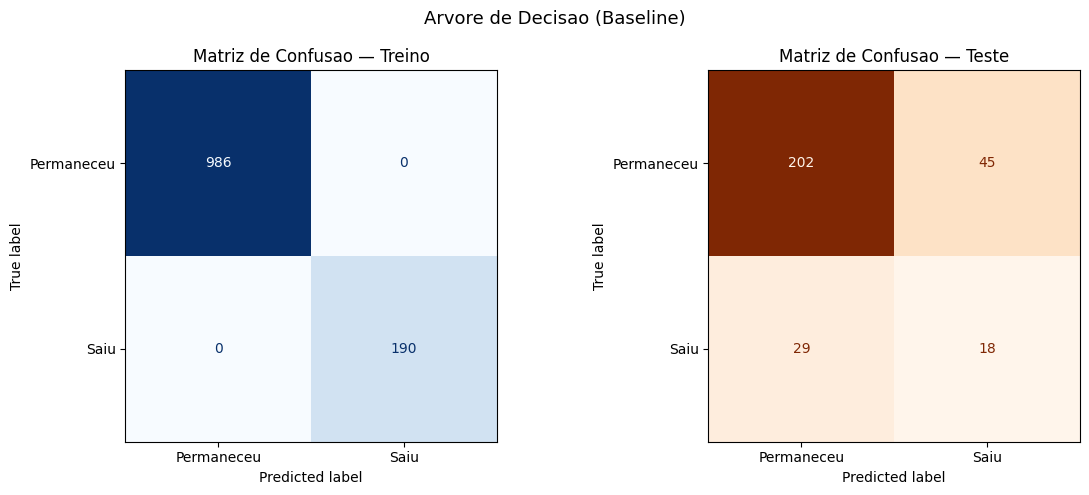

In [9]:
# 9.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)

# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_train, y_pred_train),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=["Permaneceu", "Saiu"]
).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Arvore de Decisao (Baseline)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

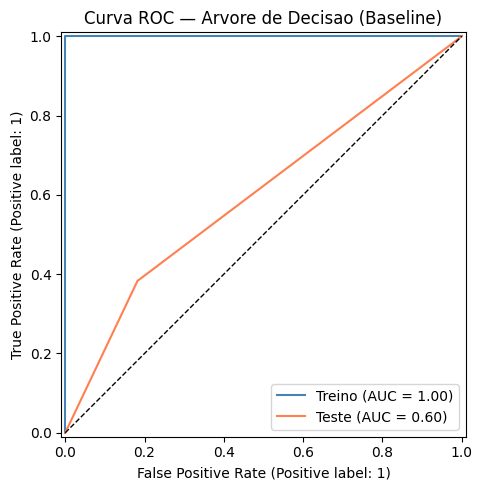

In [10]:
# 9.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)

# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore de Decisao (Baseline)")
plt.tight_layout()
plt.savefig("roc_curve_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

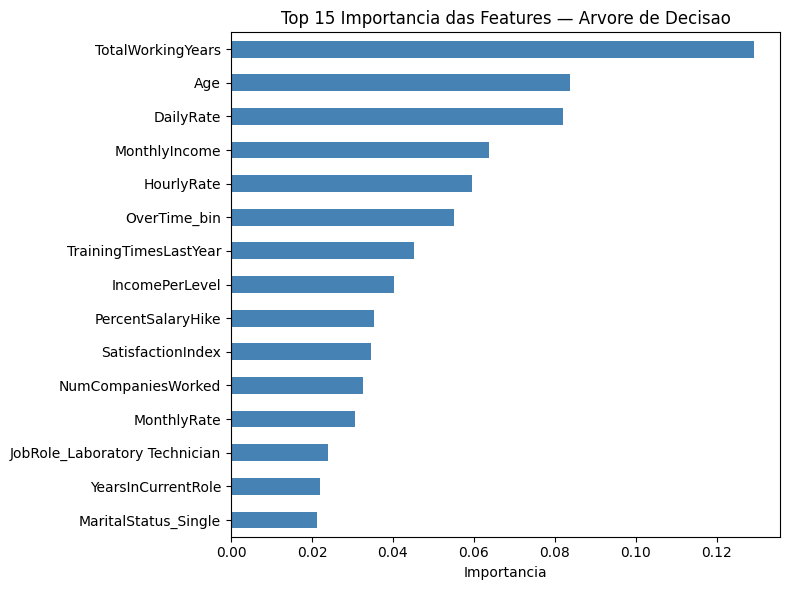

In [11]:
# 9.3 VISUALIZAÇÃO — Top 15 Importância das Features

# Cria uma série com a importância de cada feature e ordena da mais para a menos importante
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore de Decisao")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

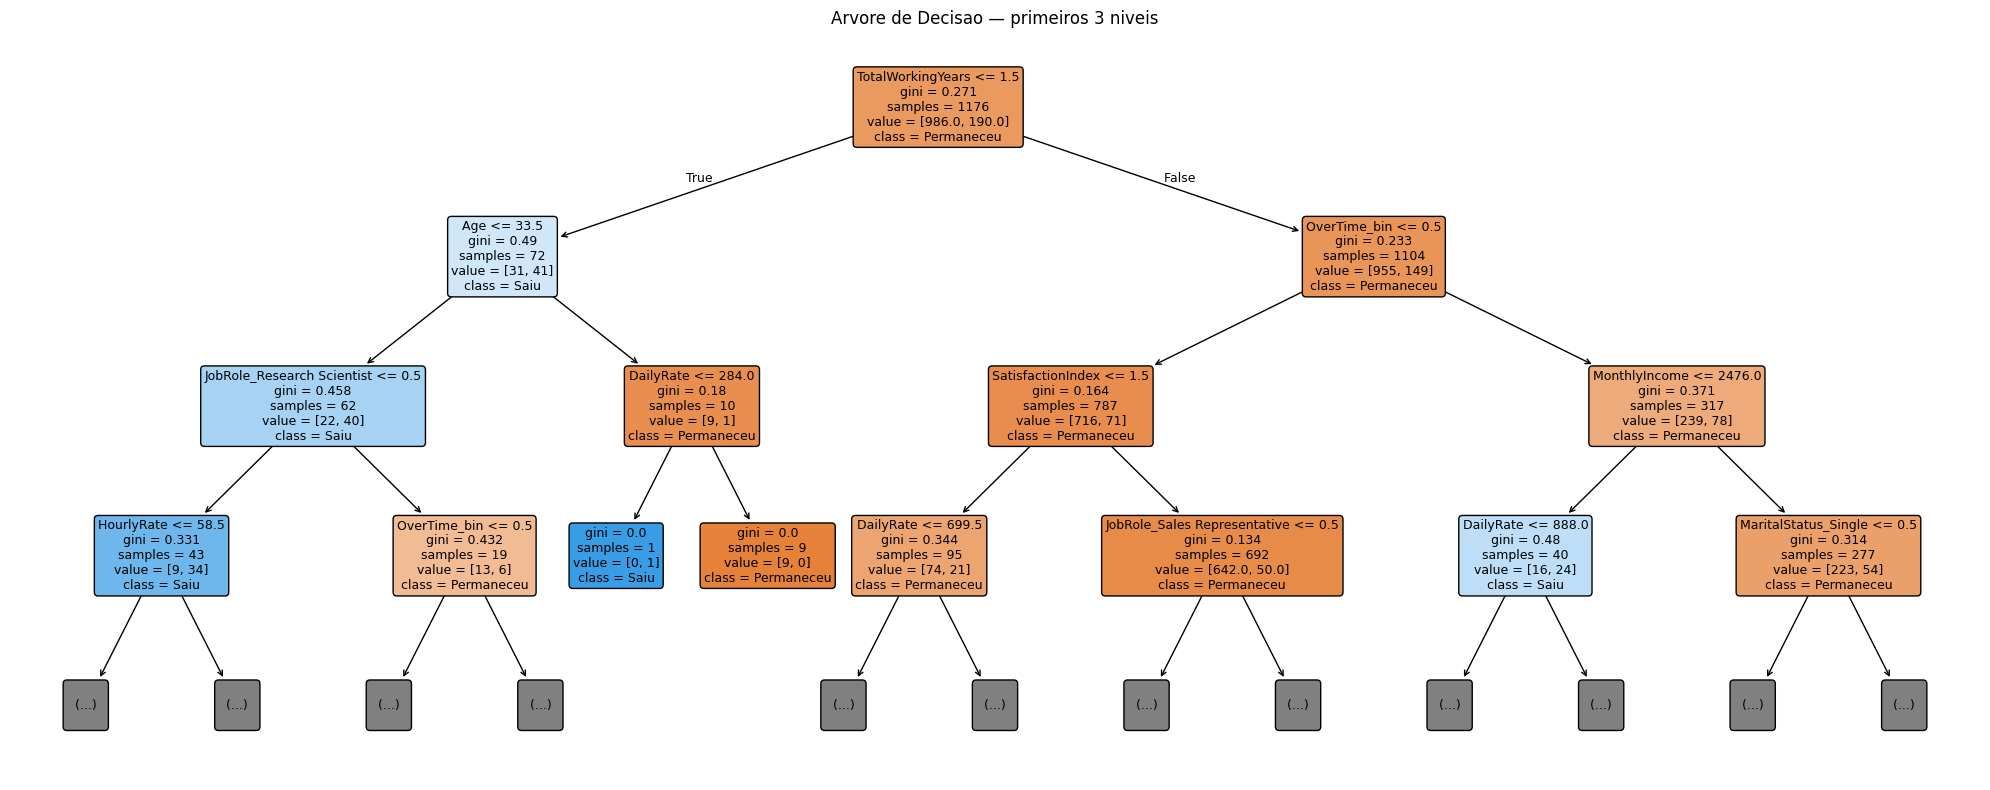

In [12]:
# 9.4 VISUALIZAÇÃO — Árvore de Decisão (primeiros 3 níveis)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf, max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# 10. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)

# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 202  OK
  FP — Permaneceu, previsto Saiu:       45  Erro
  FN — Saiu, previsto Permaneceu:       29  Erro (critico)
  TP — Saiu, previsto Saiu:             18  OK

  O modelo falhou em detetar 29 saidas reais (Falsos Negativos).


In [14]:
# 11. RESUMO FINAL

# Guarda o F1 do baseline para comparar com os candidatos
baseline_f1 = f1_score(y_test, y_pred_test)

print("=" * 55)
print("RESUMO — BASELINE")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao (parâmetros default)")
print(f"  Features:          {X.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (nao necessaria)")
print(f"  Balanceamento:     Nenhum (baseline simples)")
print(f"  Metrica principal: F1-Score")
print(f"  Profundidade:      {clf.get_depth()} niveis")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {baseline_f1:.4f}")
print()
print("  Referencial minimo para os modelos candidatos.")
print("=" * 55)

RESUMO — BASELINE
  Algoritmo:         Arvore de Decisao (parâmetros default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (nao necessaria)
  Balanceamento:     Nenhum (baseline simples)
  Metrica principal: F1-Score
  Profundidade:      15 niveis

  F1 treino: 1.0000
  F1 teste:  0.3273

  Referencial minimo para os modelos candidatos.


## CANDIDATO 1 — Random Forest

In [15]:
# 1. IMPORTAÇÕES
from sklearn.ensemble import RandomForestClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [16]:
# 2. TREINO DO MODELO
# Random Forest: conjunto de 100 árvores (default) que votam na previsão final
# random_state=42 garante reprodutibilidade
clf_rf = RandomForestClassifier(random_state=42)
# Treina todas as árvores da floresta
clf_rf.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [17]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_rf.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_rf.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [18]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_rf.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_rf.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.1695
  Precision: 0.4167
  Recall:    0.1064
  AUC-ROC:   0.7956

              precision    recall  f1-score   support

  Permaneceu       0.85      0.97      0.91       247
        Saiu       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [19]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_rf = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_rf)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.1695,0.4167,0.1064,0.7956



  Diferenca F1 (treino - teste): 0.8305
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


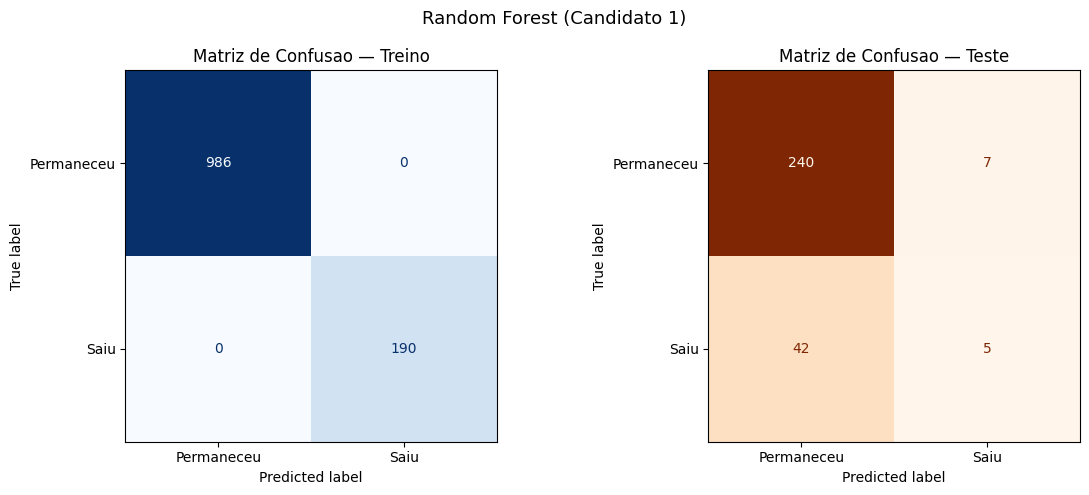

In [20]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Random Forest (Candidato 1)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()

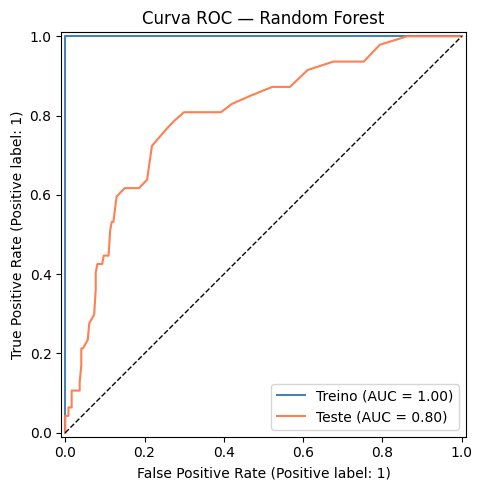

In [21]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Random Forest")
plt.tight_layout()
plt.savefig("roc_curve_rf.png", dpi=150, bbox_inches="tight")
plt.show()

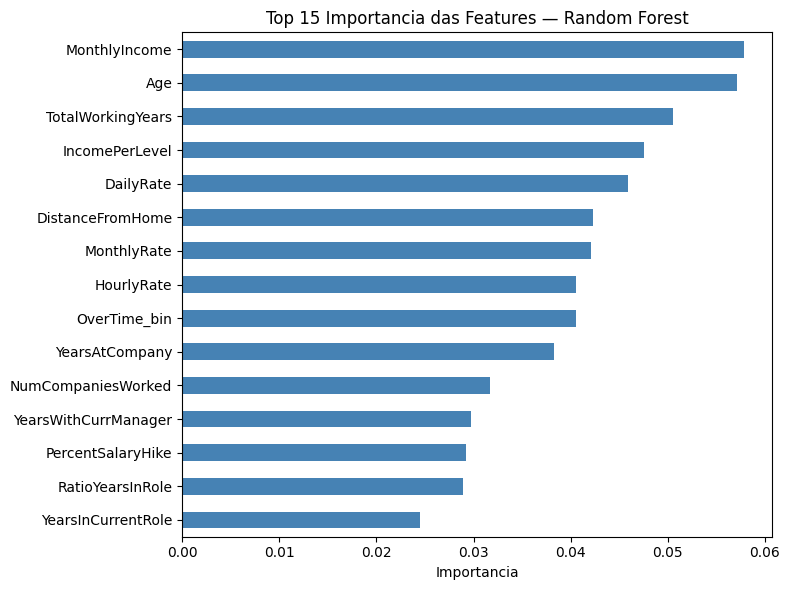

In [22]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
# Cria uma série com a importância de cada feature e ordena da mais para a menos importante
feat_imp = pd.Series(clf_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 240  OK
  FP — Permaneceu, previsto Saiu:       7  Erro
  FN — Saiu, previsto Permaneceu:       42  Erro (critico)
  TP — Saiu, previsto Saiu:             5  OK

  O modelo falhou em detetar 42 saidas reais (Falsos Negativos).


In [24]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 1")
print("=" * 55)
print(f"  Algoritmo:         Random Forest")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 1
  Algoritmo:         Random Forest
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.1695
  Baseline:  0.3273
  Melhoria:  -0.1578


## CANDIDATO 2 — Gradient Boosting

In [25]:
# 1. IMPORTAÇÕES
from sklearn.ensemble import GradientBoostingClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [26]:
# 2. TREINO DO MODELO
# Gradient Boosting: constrói árvores sequencialmente, cada uma a corrigir o erro da anterior
clf_gb = GradientBoostingClassifier(random_state=42)
# Treina o modelo de forma sequencial (boosting)
clf_gb.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [27]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_gb.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_gb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.8520
  Precision: 1.0000
  Recall:    0.7421
  AUC-ROC:   0.9855

              precision    recall  f1-score   support

  Permaneceu       0.95      1.00      0.98       986
        Saiu       1.00      0.74      0.85       190

    accuracy                           0.96      1176
   macro avg       0.98      0.87      0.91      1176
weighted avg       0.96      0.96      0.96      1176



In [28]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_gb.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_gb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3175
  Precision: 0.6250
  Recall:    0.2128
  AUC-ROC:   0.8091

              precision    recall  f1-score   support

  Permaneceu       0.87      0.98      0.92       247
        Saiu       0.62      0.21      0.32        47

    accuracy                           0.85       294
   macro avg       0.75      0.59      0.62       294
weighted avg       0.83      0.85      0.82       294



In [29]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_gb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_gb)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.8520,1.000,0.7421,0.9855
1,Teste,0.3175,0.625,0.2128,0.8091



  Diferenca F1 (treino - teste): 0.5345
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


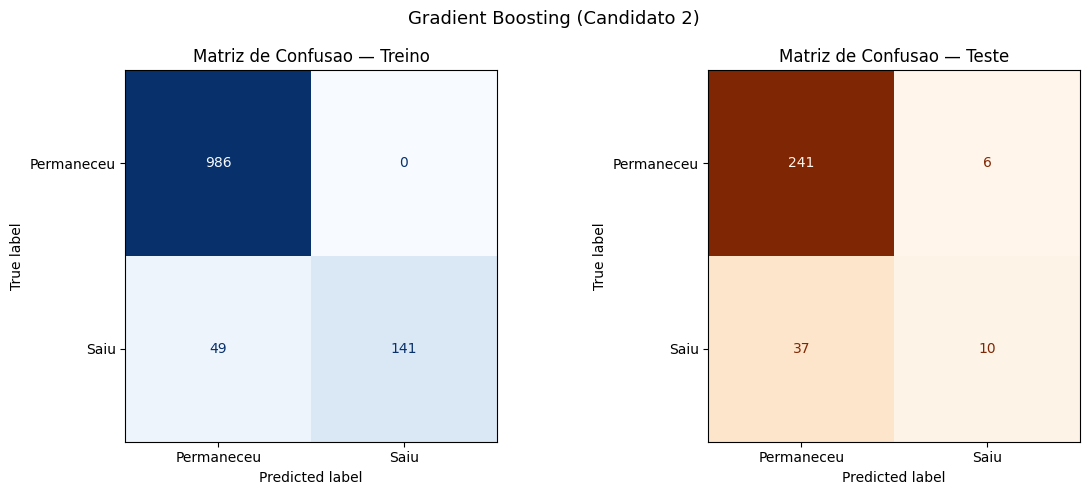

In [30]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Gradient Boosting (Candidato 2)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_gb.png", dpi=150, bbox_inches="tight")
plt.show()

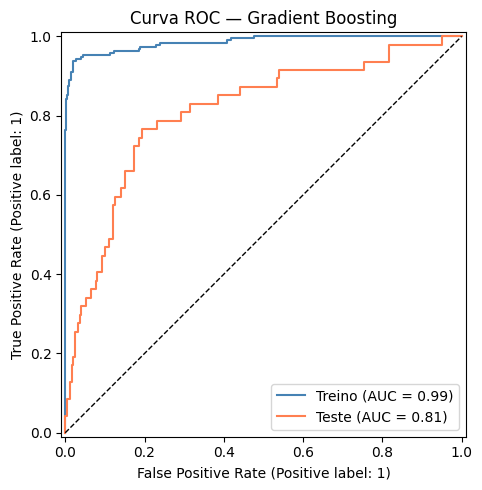

In [31]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Gradient Boosting")
plt.tight_layout()
plt.savefig("roc_curve_gb.png", dpi=150, bbox_inches="tight")
plt.show()

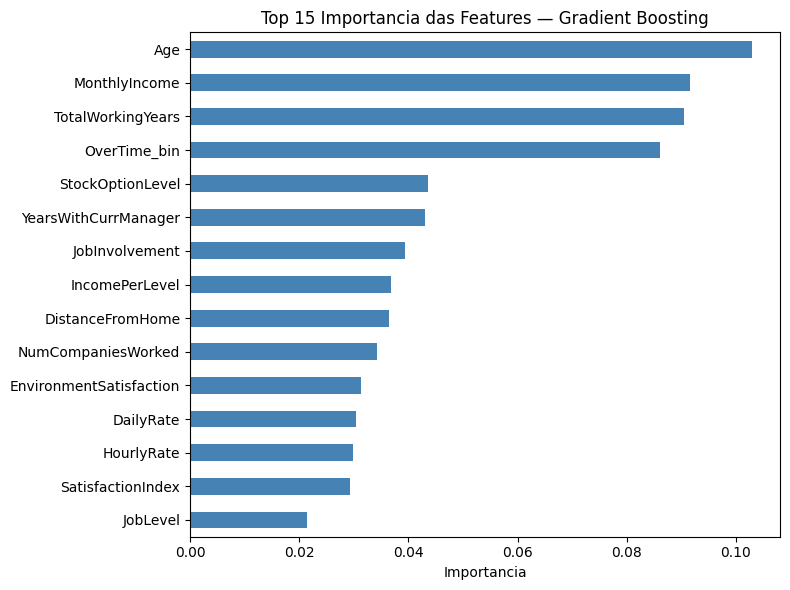

In [32]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
# Cria uma série com a importância de cada feature e ordena da mais para a menos importante
feat_imp = pd.Series(clf_gb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Gradient Boosting")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_gb.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 241  OK
  FP — Permaneceu, previsto Saiu:       6  Erro
  FN — Saiu, previsto Permaneceu:       37  Erro (critico)
  TP — Saiu, previsto Saiu:             10  OK

  O modelo falhou em detetar 37 saidas reais (Falsos Negativos).


In [34]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 2")
print("=" * 55)
print(f"  Algoritmo:         Gradient Boosting")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 2
  Algoritmo:         Gradient Boosting
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.8520
  F1 teste:  0.3175
  Baseline:  0.3273
  Melhoria:  -0.0098


## CANDIDATO 3 — XGBoost

In [35]:
# 1. IMPORTAÇÕES
from xgboost import XGBClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [36]:
# 2. TREINO DO MODELO
# XGBoost: versão otimizada de Gradient Boosting, muito eficiente e popular em competições
# eval_metric="logloss" define a métrica de avaliação interna
clf_xgb = XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False)
# Treina o XGBoost
clf_xgb.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [37]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_xgb.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_xgb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [38]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_xgb.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_xgb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3333
  Precision: 0.5789
  Recall:    0.2340
  AUC-ROC:   0.7617

              precision    recall  f1-score   support

  Permaneceu       0.87      0.97      0.92       247
        Saiu       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



In [39]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_xgb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_xgb)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.000,1.0000
1,Teste,0.3333,0.5789,0.234,0.7617



  Diferenca F1 (treino - teste): 0.6667
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


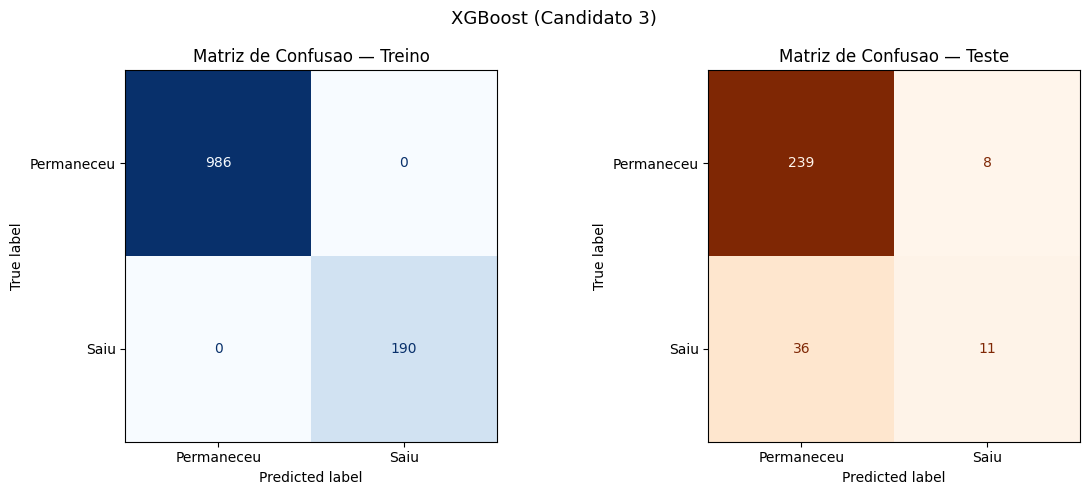

In [40]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("XGBoost (Candidato 3)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

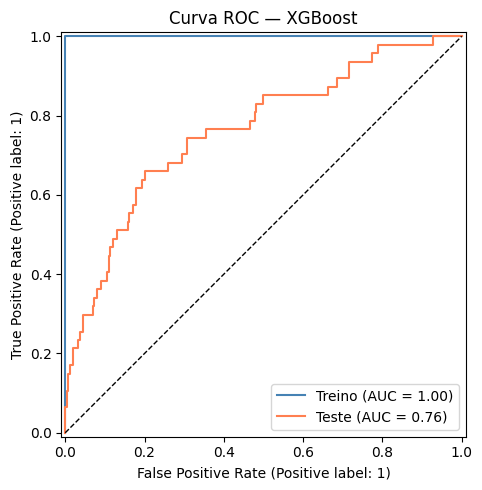

In [41]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — XGBoost")
plt.tight_layout()
plt.savefig("roc_curve_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

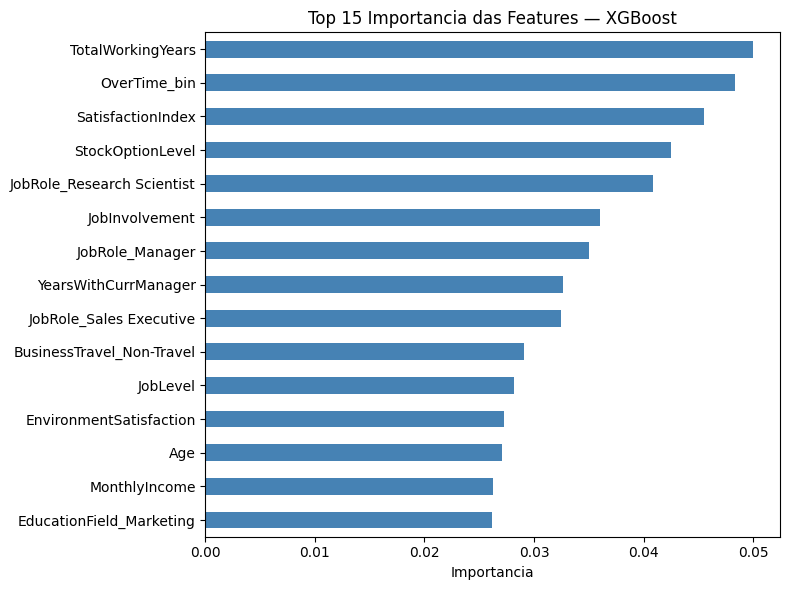

In [42]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
# Cria uma série com a importância de cada feature e ordena da mais para a menos importante
feat_imp = pd.Series(clf_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — XGBoost")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 239  OK
  FP — Permaneceu, previsto Saiu:       8  Erro
  FN — Saiu, previsto Permaneceu:       36  Erro (critico)
  TP — Saiu, previsto Saiu:             11  OK

  O modelo falhou em detetar 36 saidas reais (Falsos Negativos).


In [44]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 3")
print("=" * 55)
print(f"  Algoritmo:         XGBoost")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 3
  Algoritmo:         XGBoost
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.3333
  Baseline:  0.3273
  Melhoria:  +0.0061


## CANDIDATO 4 — LightGBM

In [45]:
# 1. IMPORTAÇÕES
from lightgbm import LGBMClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [46]:
# 2. TREINO DO MODELO
# LightGBM: boosting baseado em histogramas, mais rápido que XGBoost em datasets grandes
# verbose=-1 silencia os logs de treino
clf_lgbm = LGBMClassifier(random_state=42, verbose=-1)
# Treina o LightGBM
clf_lgbm.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [47]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_lgbm.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_lgbm.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [48]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_lgbm.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_lgbm.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3548
  Precision: 0.7333
  Recall:    0.2340
  AUC-ROC:   0.7820

              precision    recall  f1-score   support

  Permaneceu       0.87      0.98      0.92       247
        Saiu       0.73      0.23      0.35        47

    accuracy                           0.86       294
   macro avg       0.80      0.61      0.64       294
weighted avg       0.85      0.86      0.83       294



In [49]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_lgbm = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lgbm)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.000,1.000
1,Teste,0.3548,0.7333,0.234,0.782



  Diferenca F1 (treino - teste): 0.6452
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


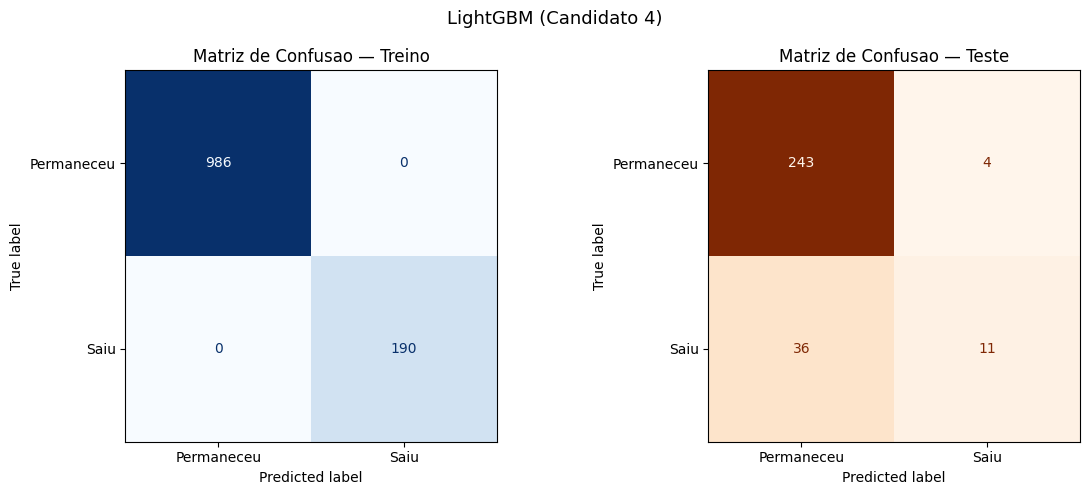

In [50]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("LightGBM (Candidato 4)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

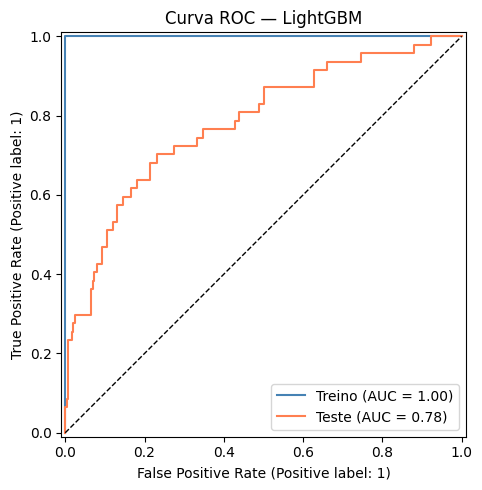

In [51]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — LightGBM")
plt.tight_layout()
plt.savefig("roc_curve_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

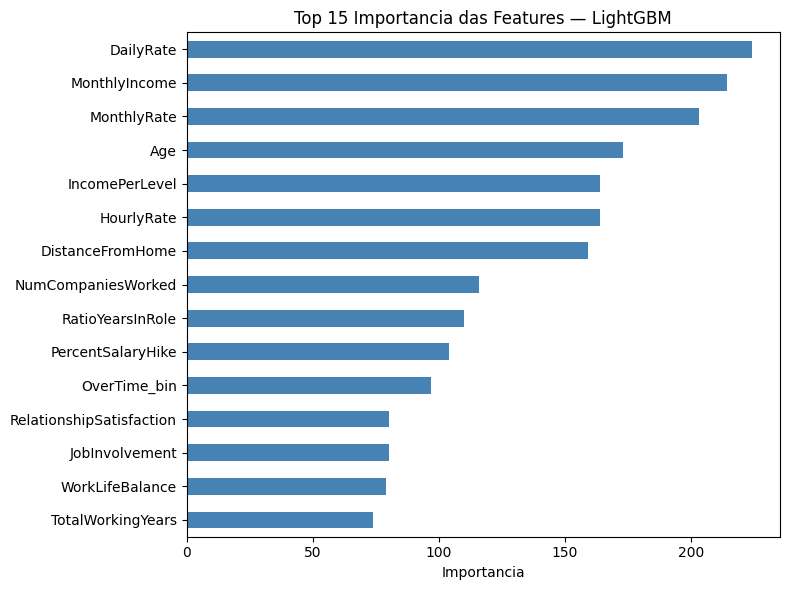

In [52]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
# Cria uma série com a importância de cada feature e ordena da mais para a menos importante
feat_imp = pd.Series(clf_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — LightGBM")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_lgbm.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 243  OK
  FP — Permaneceu, previsto Saiu:       4  Erro
  FN — Saiu, previsto Permaneceu:       36  Erro (critico)
  TP — Saiu, previsto Saiu:             11  OK

  O modelo falhou em detetar 36 saidas reais (Falsos Negativos).


In [54]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 4")
print("=" * 55)
print(f"  Algoritmo:         LightGBM")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 4
  Algoritmo:         LightGBM
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.3548
  Baseline:  0.3273
  Melhoria:  +0.0276


## CANDIDATO 5 — CatBoost

In [55]:
# 1. IMPORTAÇÕES
from catboost import CatBoostClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [56]:
# 2. TREINO DO MODELO
# CatBoost: boosting otimizado para variáveis categóricas, robusto sem pré-processamento
# verbose=0 silencia os logs de treino
clf_cat = CatBoostClassifier(random_state=42, verbose=0)
# Treina o CatBoost
clf_cat.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [57]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_cat.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_cat.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.9532
  Precision: 1.0000
  Recall:    0.9105
  AUC-ROC:   0.9999

              precision    recall  f1-score   support

  Permaneceu       0.98      1.00      0.99       986
        Saiu       1.00      0.91      0.95       190

    accuracy                           0.99      1176
   macro avg       0.99      0.96      0.97      1176
weighted avg       0.99      0.99      0.99      1176



In [58]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_cat.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_cat.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2667
  Precision: 0.6154
  Recall:    0.1702
  AUC-ROC:   0.8017

              precision    recall  f1-score   support

  Permaneceu       0.86      0.98      0.92       247
        Saiu       0.62      0.17      0.27        47

    accuracy                           0.85       294
   macro avg       0.74      0.57      0.59       294
weighted avg       0.82      0.85      0.81       294



In [59]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_cat = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_cat)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.9532,1.0000,0.9105,0.9999
1,Teste,0.2667,0.6154,0.1702,0.8017



  Diferenca F1 (treino - teste): 0.6865
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


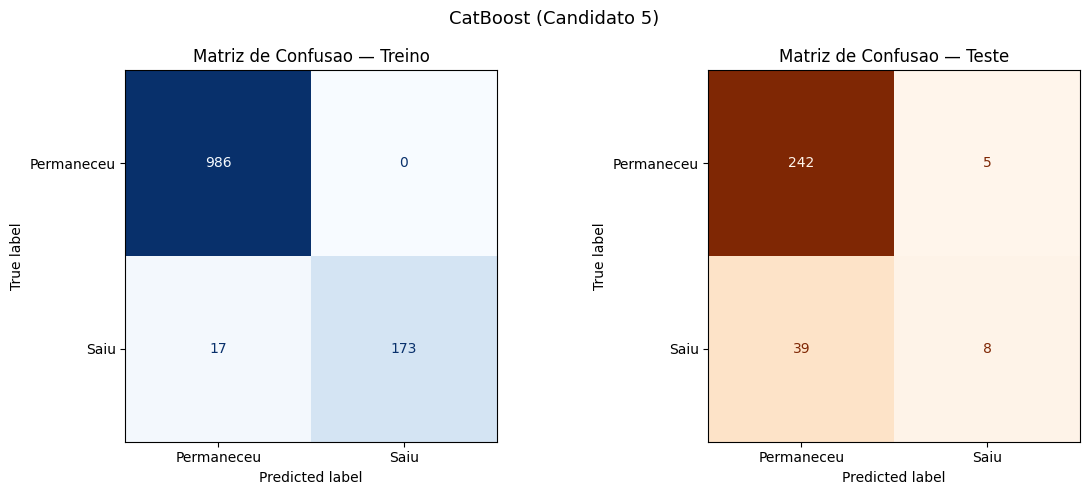

In [60]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("CatBoost (Candidato 5)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_cat.png", dpi=150, bbox_inches="tight")
plt.show()

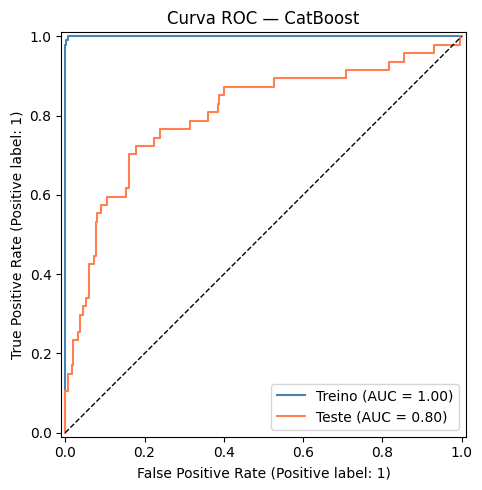

In [61]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — CatBoost")
plt.tight_layout()
plt.savefig("roc_curve_cat.png", dpi=150, bbox_inches="tight")
plt.show()

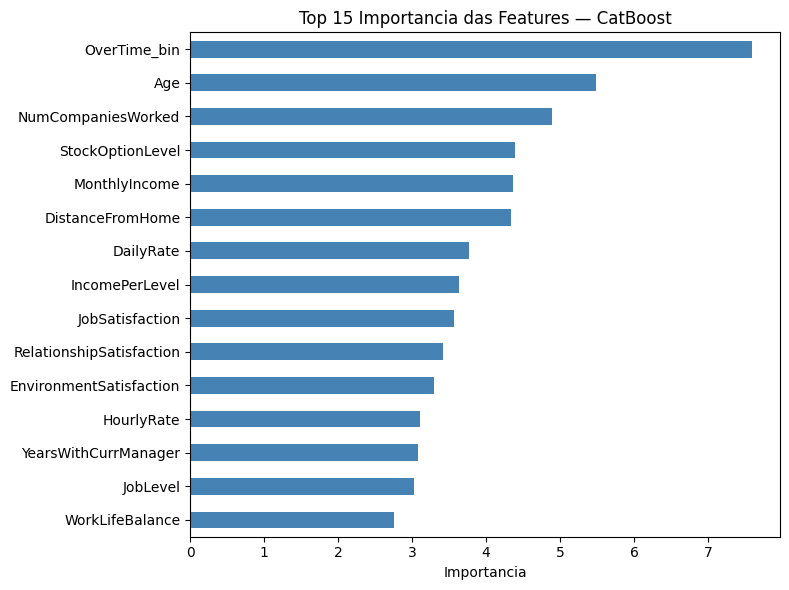

In [62]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
# Cria uma série com a importância de cada feature e ordena da mais para a menos importante
feat_imp = pd.Series(clf_cat.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — CatBoost")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_cat.png", dpi=150, bbox_inches="tight")
plt.show()

In [63]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 242  OK
  FP — Permaneceu, previsto Saiu:       5  Erro
  FN — Saiu, previsto Permaneceu:       39  Erro (critico)
  TP — Saiu, previsto Saiu:             8  OK

  O modelo falhou em detetar 39 saidas reais (Falsos Negativos).


In [64]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 5")
print("=" * 55)
print(f"  Algoritmo:         CatBoost")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 5
  Algoritmo:         CatBoost
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.9532
  F1 teste:  0.2667
  Baseline:  0.3273
  Melhoria:  -0.0606


## CANDIDATO 6 — SVM

In [65]:
# 1. IMPORTAÇÕES
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [66]:
# 2. TREINO DO MODELO
# SVM requer normalização — Pipeline garante que o scaler
# é ajustado só no treino, sem data leakage
# probability=True necessário para predict_proba()
# Pipeline que primeiro normaliza os dados (StandardScaler) e depois aplica o SVM
# O Pipeline evita data leakage: o scaler aprende só com os dados de treino
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),  # Normaliza para média=0 e desvio=1 (obrigatório para SVM)
    ("clf",    SVC(probability=True, random_state=42))  # probability=True permite usar predict_proba() para AUC-ROC
])
# Treina o Pipeline (normaliza os dados e depois treina o SVM)
pipeline_svm.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [67]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = pipeline_svm.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = pipeline_svm.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6851
  Precision: 1.0000
  Recall:    0.5211
  AUC-ROC:   0.9654

              precision    recall  f1-score   support

  Permaneceu       0.92      1.00      0.96       986
        Saiu       1.00      0.52      0.69       190

    accuracy                           0.92      1176
   macro avg       0.96      0.76      0.82      1176
weighted avg       0.93      0.92      0.91      1176



In [68]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = pipeline_svm.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = pipeline_svm.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2712
  Precision: 0.6667
  Recall:    0.1702
  AUC-ROC:   0.8086

              precision    recall  f1-score   support

  Permaneceu       0.86      0.98      0.92       247
        Saiu       0.67      0.17      0.27        47

    accuracy                           0.85       294
   macro avg       0.76      0.58      0.59       294
weighted avg       0.83      0.85      0.82       294



In [69]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_svm = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_svm)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6851,1.0000,0.5211,0.9654
1,Teste,0.2712,0.6667,0.1702,0.8086



  Diferenca F1 (treino - teste): 0.4139
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


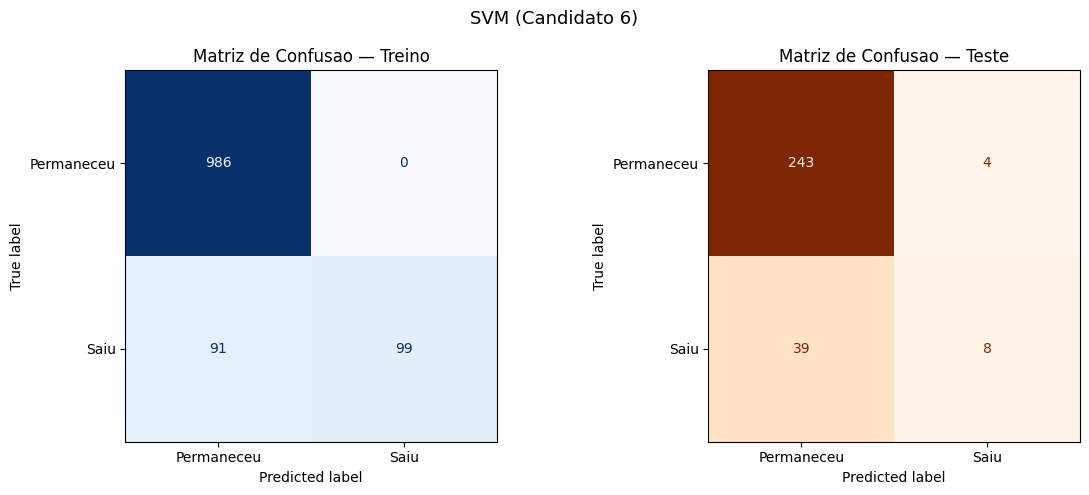

In [70]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("SVM (Candidato 6)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_svm.png", dpi=150, bbox_inches="tight")
plt.show()

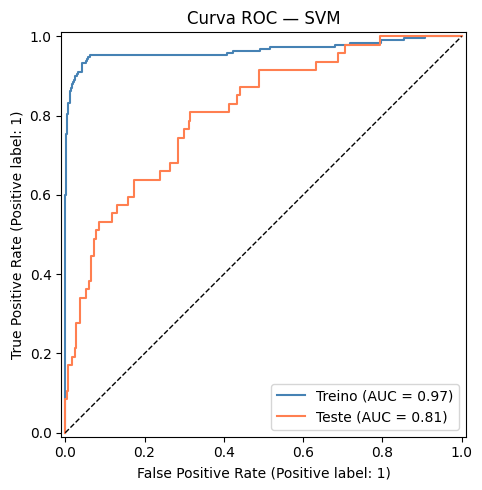

In [71]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — SVM")
plt.tight_layout()
plt.savefig("roc_curve_svm.png", dpi=150, bbox_inches="tight")
plt.show()

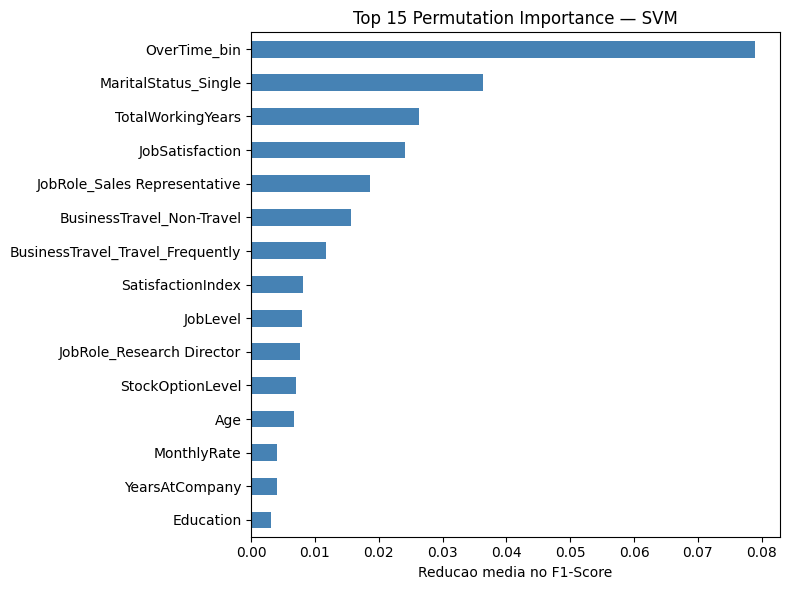

In [72]:
# 6.3 VISUALIZAÇÃO — Permutation Importance (SVM)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    pipeline_svm, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

feat_imp = pd.Series(perm.importances_mean, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Permutation Importance — SVM")
ax.set_xlabel("Reducao media no F1-Score")
plt.tight_layout()
plt.savefig("feature_importance_svm.png", dpi=150, bbox_inches="tight")
plt.show()

In [73]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 243  OK
  FP — Permaneceu, previsto Saiu:       4  Erro
  FN — Saiu, previsto Permaneceu:       39  Erro (critico)
  TP — Saiu, previsto Saiu:             8  OK

  O modelo falhou em detetar 39 saidas reais (Falsos Negativos).


In [74]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 6")
print("=" * 55)
print(f"  Algoritmo:         SVM (kernel RBF)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler (obrigatoria para SVM)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 6
  Algoritmo:         SVM (kernel RBF)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler (obrigatoria para SVM)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6851
  F1 teste:  0.2712
  Baseline:  0.3273
  Melhoria:  -0.0561


## CANDIDATO 7 — Árvore de Decisão com Pruning

In [75]:
# 1. IMPORTAÇÕES
from sklearn.tree import DecisionTreeClassifier, plot_tree
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [76]:
# 2. TREINO DO MODELO
# ccp_alpha controla o nivel de poda
# quanto maior o valor, mais simples fica a arvore
# objetivo: reduzir o overfitting do baseline
# Árvore com poda por custo-complexidade
# ccp_alpha=0.005: quanto maior, mais a árvore é podada (mais simples, menos overfitting)
clf_pruned = DecisionTreeClassifier(ccp_alpha=0.005, random_state=42)
# Treina a árvore podada
clf_pruned.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Profundidade da arvore: {clf_pruned.get_depth()}")
print(f"  Numero de folhas:       {clf_pruned.get_n_leaves()}")
print(f"  ccp_alpha:              {clf_pruned.ccp_alpha}")

Modelo treinado.
  Profundidade da arvore: 4
  Numero de folhas:       5
  ccp_alpha:              0.005


In [77]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_pruned.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_pruned.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4305
  Precision: 0.5804
  Recall:    0.3421
  AUC-ROC:   0.7184

              precision    recall  f1-score   support

  Permaneceu       0.88      0.95      0.92       986
        Saiu       0.58      0.34      0.43       190

    accuracy                           0.85      1176
   macro avg       0.73      0.65      0.67      1176
weighted avg       0.83      0.85      0.84      1176



In [78]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_pruned.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_pruned.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3117
  Precision: 0.4000
  Recall:    0.2553
  AUC-ROC:   0.7272

              precision    recall  f1-score   support

  Permaneceu       0.87      0.93      0.90       247
        Saiu       0.40      0.26      0.31        47

    accuracy                           0.82       294
   macro avg       0.63      0.59      0.60       294
weighted avg       0.79      0.82      0.80       294



In [79]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_pruned = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_pruned)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4305,0.5804,0.3421,0.7184
1,Teste,0.3117,0.4000,0.2553,0.7272



  Diferenca F1 (treino - teste): 0.1188
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


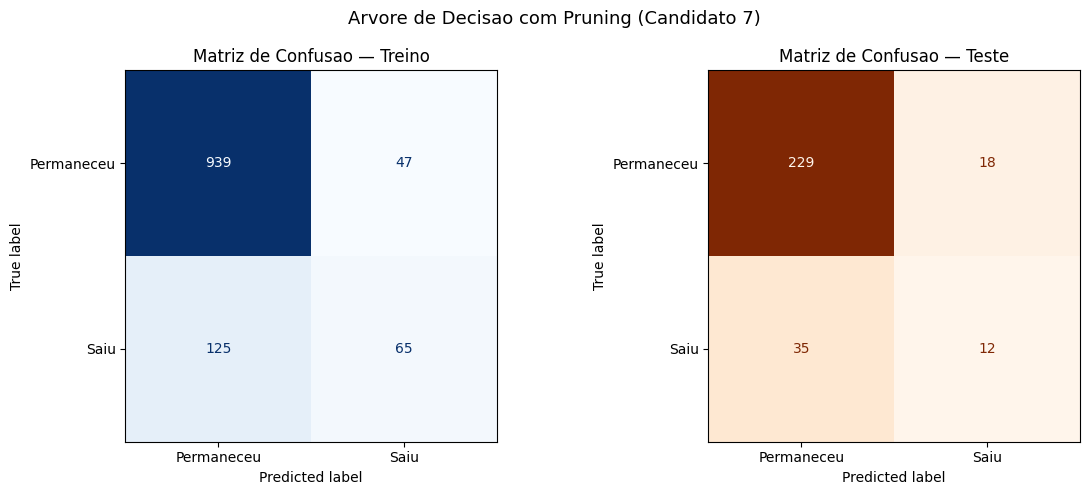

In [80]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Arvore de Decisao com Pruning (Candidato 7)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

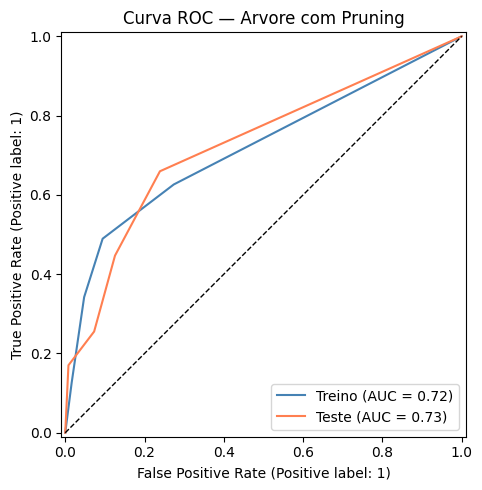

In [81]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Arvore com Pruning")
plt.tight_layout()
plt.savefig("roc_curve_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

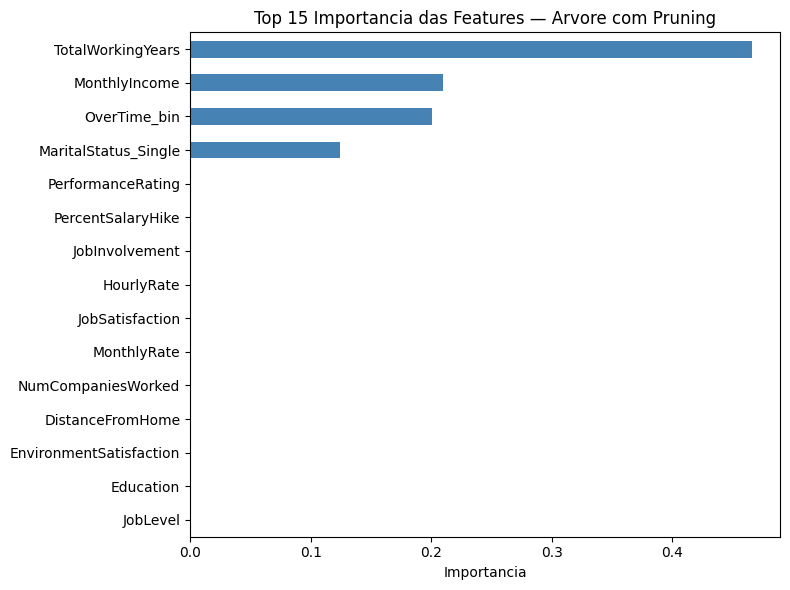

In [82]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
# Cria uma série com a importância de cada feature e ordena da mais para a menos importante
feat_imp = pd.Series(clf_pruned.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Arvore com Pruning")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

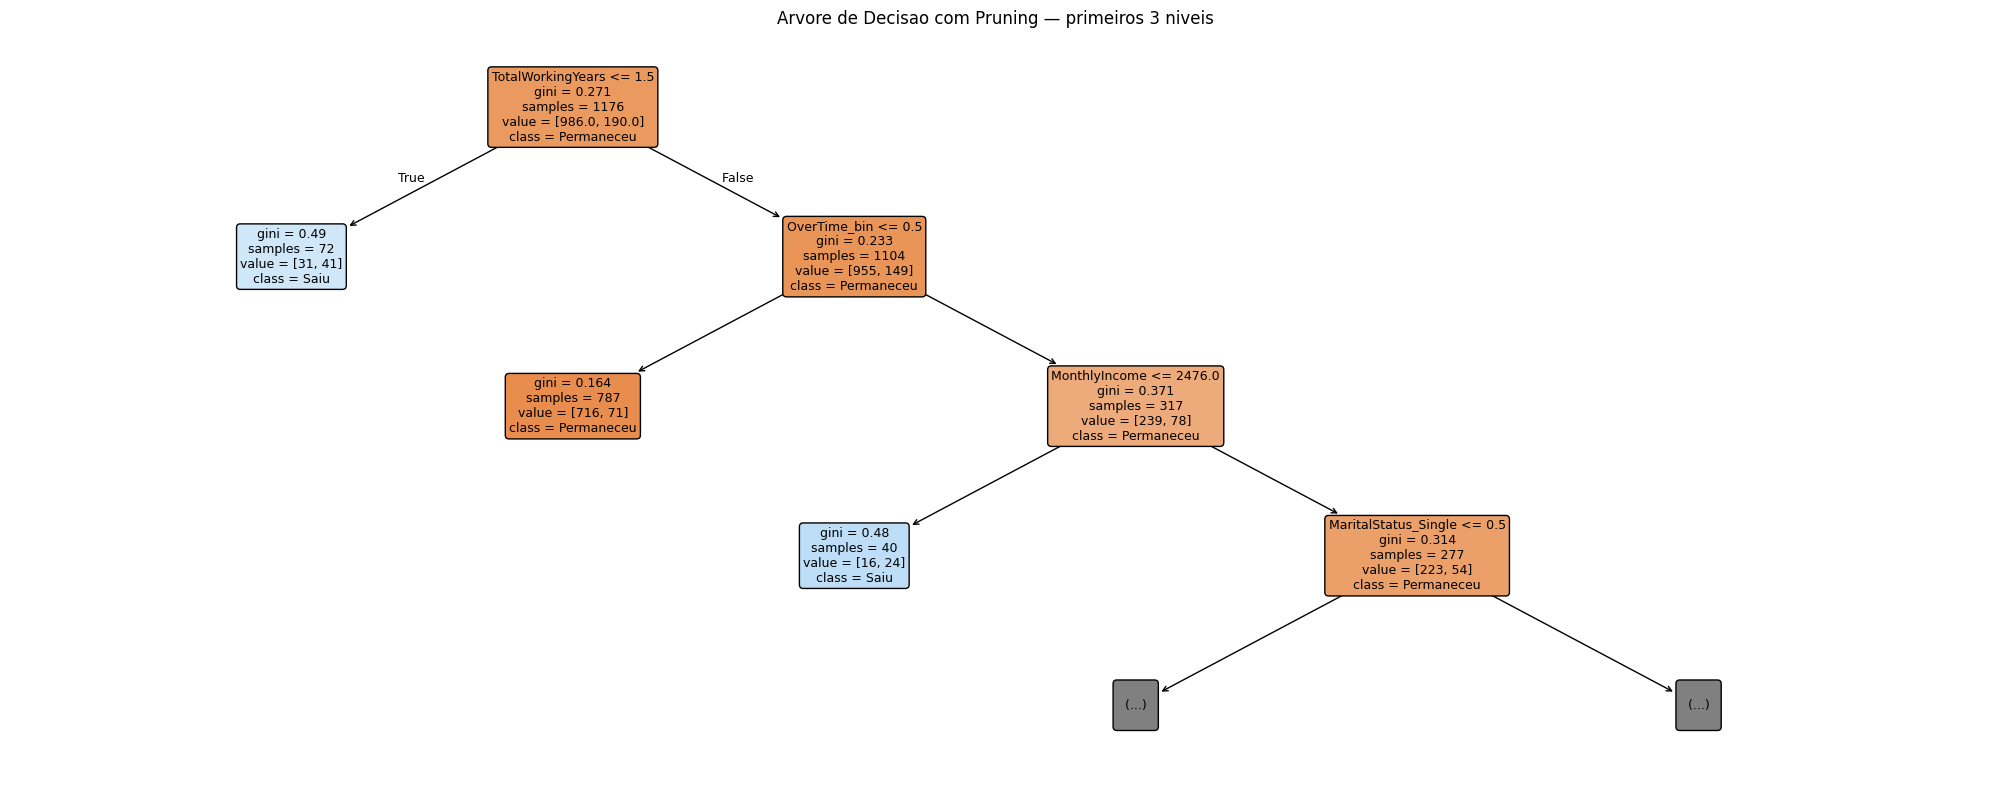

In [83]:
# 6.4 VISUALIZAÇÃO — Árvore de Decisão com Pruning (primeiros 3 níveis)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf_pruned, max_depth=3,
    feature_names=X_train.columns.tolist(),
    class_names=["Permaneceu", "Saiu"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title("Arvore de Decisao com Pruning — primeiros 3 niveis")
plt.tight_layout()
plt.savefig("decision_tree_pruned.png", dpi=150, bbox_inches="tight")
plt.show()

In [84]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 229  OK
  FP — Permaneceu, previsto Saiu:       18  Erro
  FN — Saiu, previsto Permaneceu:       35  Erro (critico)
  TP — Saiu, previsto Saiu:             12  OK

  O modelo falhou em detetar 35 saidas reais (Falsos Negativos).


In [85]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 7")
print("=" * 55)
print(f"  Algoritmo:         Arvore de Decisao com Pruning")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  ccp_alpha:         {clf_pruned.ccp_alpha}")
print(f"  Profundidade:      {clf_pruned.get_depth()} niveis")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 7
  Algoritmo:         Arvore de Decisao com Pruning
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  ccp_alpha:         0.005
  Profundidade:      4 niveis
  Metrica principal: F1-Score

  F1 treino: 0.4305
  F1 teste:  0.3117
  Baseline:  0.3273
  Melhoria:  -0.0156


## CANDIDATO 8 — Regressão Logística

In [86]:
# 1. IMPORTAÇÕES
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [87]:
# 2. TREINO DO MODELO
# Pipeline com normalização (necessário para regressão logística)
# Pipeline: normaliza primeiro, depois aplica Regressão Logística
# A normalização é necessária porque a RegLog é sensível à escala das variáveis
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(random_state=42))
])
# Treina o Pipeline (normaliza + ajusta os coeficientes logísticos)
pipeline_lr.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Coeficientes: {pipeline_lr.named_steps['clf'].coef_.shape}")

Modelo treinado.
  Coeficientes: (1, 53)


In [88]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = pipeline_lr.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = pipeline_lr.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6519
  Precision: 0.8175
  Recall:    0.5421
  AUC-ROC:   0.8819

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.54      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.76      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [89]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = pipeline_lr.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = pipeline_lr.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4595
  Precision: 0.6296
  Recall:    0.3617
  AUC-ROC:   0.8170

              precision    recall  f1-score   support

  Permaneceu       0.89      0.96      0.92       247
        Saiu       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



In [90]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_lr = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lr)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6519,0.8175,0.5421,0.8819
1,Teste,0.4595,0.6296,0.3617,0.8170



  Diferenca F1 (treino - teste): 0.1924
  --> Sinal de OVERFITTING.


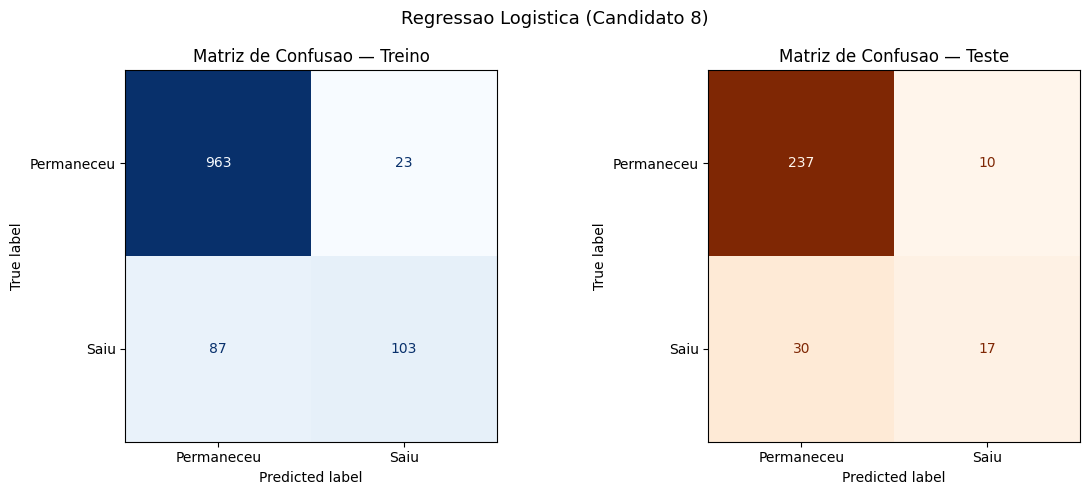

In [91]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Regressao Logistica (Candidato 8)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()

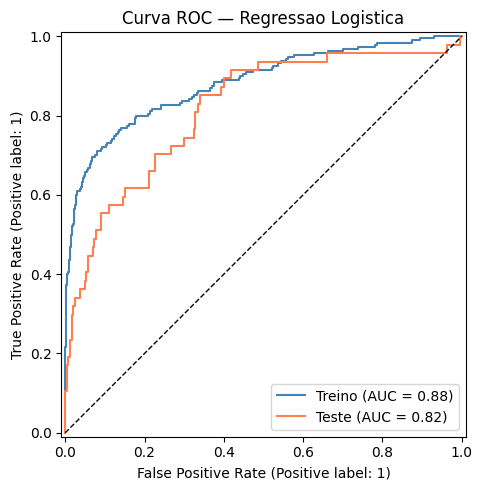

In [92]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Regressao Logistica")
plt.tight_layout()
plt.savefig("roc_curve_lr.png", dpi=150, bbox_inches="tight")
plt.show()

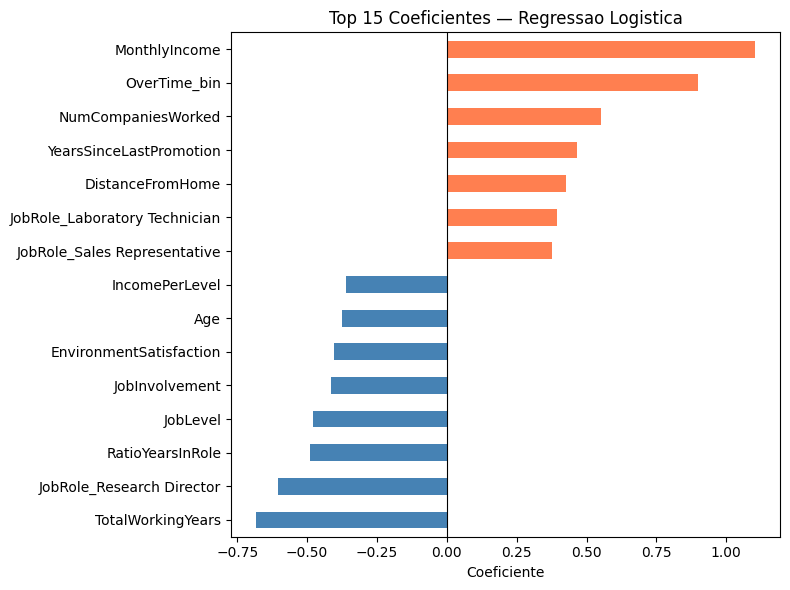

In [93]:
# 6.3 VISUALIZAÇÃO — Top 15 Coeficientes (interpretabilidade)
coef = pd.Series(
    pipeline_lr.named_steps["clf"].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
coef.sort_values().plot(kind="barh", ax=ax, color=["coral" if v > 0 else "steelblue" for v in coef.sort_values()])
ax.set_title("Top 15 Coeficientes — Regressao Logistica")
ax.set_xlabel("Coeficiente")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig("coef_lr.png", dpi=150, bbox_inches="tight")
plt.show()

In [94]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 237  OK
  FP — Permaneceu, previsto Saiu:       10  Erro
  FN — Saiu, previsto Permaneceu:       30  Erro (critico)
  TP — Saiu, previsto Saiu:             17  OK

  O modelo falhou em detetar 30 saidas reais (Falsos Negativos).


In [95]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 8")
print("=" * 55)
print(f"  Algoritmo:         Regressao Logistica")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 8
  Algoritmo:         Regressao Logistica
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6519
  F1 teste:  0.4595
  Baseline:  0.3273
  Melhoria:  +0.1322


## CANDIDATO 9 — Linear Discriminant Analysis (LDA)

In [96]:
# 1. IMPORTAÇÕES
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [97]:
# 2. TREINO DO MODELO
# LDA: encontra a combinação linear de features que melhor separa as classes
# Não requer normalização explícita (faz internamente)
clf_lda = LinearDiscriminantAnalysis()
# Treina o LDA
clf_lda.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Componentes discriminantes: {clf_lda.scalings_.shape}")

Modelo treinado.
  Componentes discriminantes: (53, 1)


In [98]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_lda.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_lda.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6454
  Precision: 0.8211
  Recall:    0.5316
  AUC-ROC:   0.8735

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.53      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.75      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [99]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_lda.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_lda.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4167
  Precision: 0.6000
  Recall:    0.3191
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.88      0.96      0.92       247
        Saiu       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



In [100]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_lda = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_lda)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6454,0.8211,0.5316,0.8735
1,Teste,0.4167,0.6000,0.3191,0.8099



  Diferenca F1 (treino - teste): 0.2287
  --> Sinal de OVERFITTING.


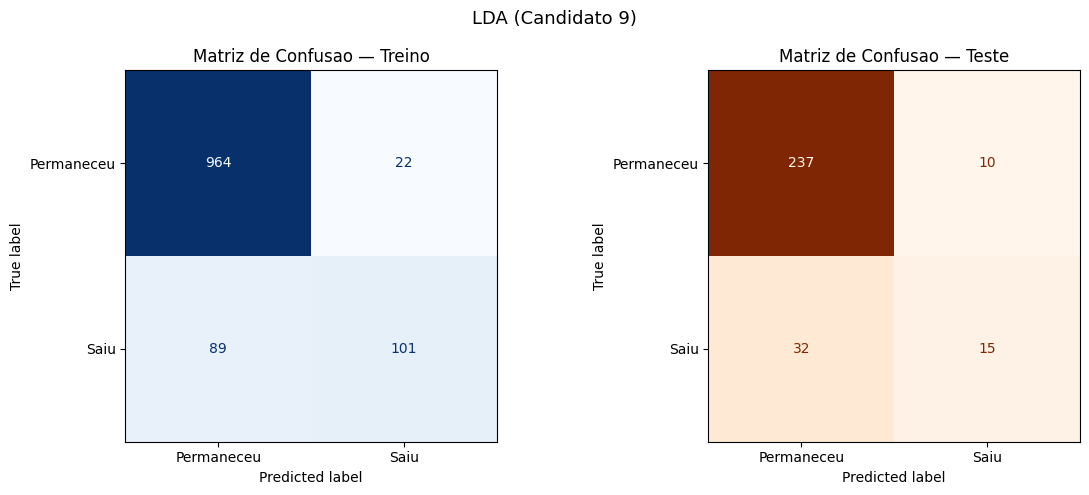

In [101]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("LDA (Candidato 9)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_lda.png", dpi=150, bbox_inches="tight")
plt.show()

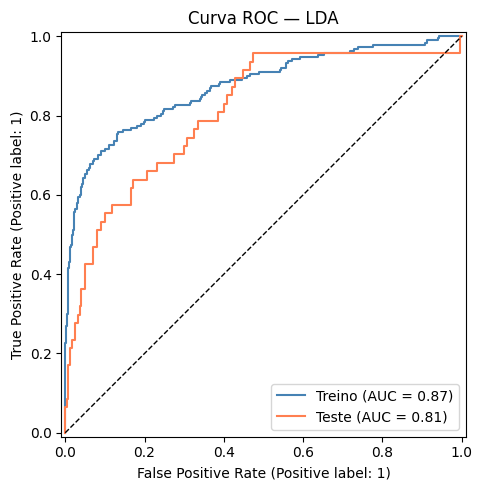

In [102]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — LDA")
plt.tight_layout()
plt.savefig("roc_curve_lda.png", dpi=150, bbox_inches="tight")
plt.show()

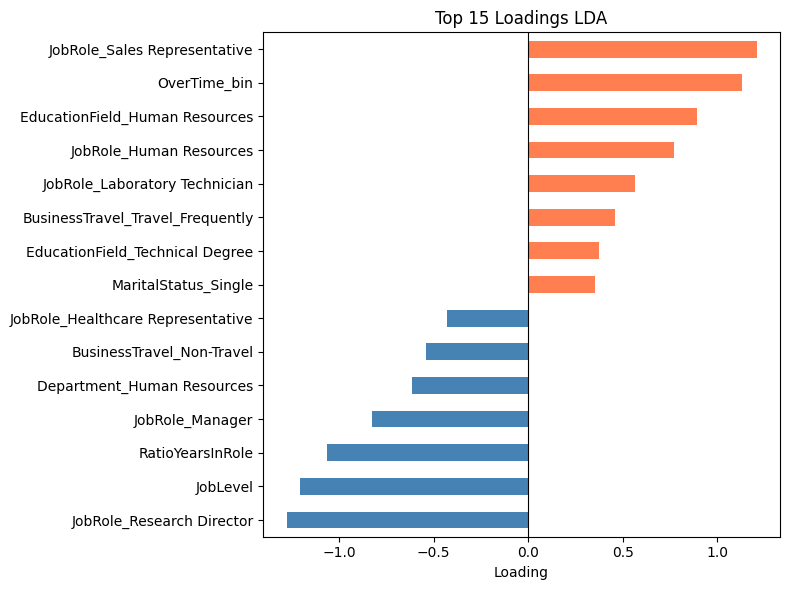

In [103]:
# 6.3 VISUALIZAÇÃO — Top 15 Loadings LDA (interpretabilidade)
loadings = pd.Series(clf_lda.scalings_[:, 0], index=X_train.columns).sort_values(key=abs, ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
loadings.sort_values().plot(kind="barh", ax=ax, color=["coral" if v > 0 else "steelblue" for v in loadings.sort_values()])
ax.set_title("Top 15 Loadings LDA")
ax.set_xlabel("Loading")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig("loadings_lda.png", dpi=150, bbox_inches="tight")
plt.show()

In [104]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 237  OK
  FP — Permaneceu, previsto Saiu:       10  Erro
  FN — Saiu, previsto Permaneceu:       32  Erro (critico)
  TP — Saiu, previsto Saiu:             15  OK

  O modelo falhou em detetar 32 saidas reais (Falsos Negativos).


In [105]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 9")
print("=" * 55)
print(f"  Algoritmo:         Linear Discriminant Analysis")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma (LDA faz internamente)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 9
  Algoritmo:         Linear Discriminant Analysis
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma (LDA faz internamente)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6454
  F1 teste:  0.4167
  Baseline:  0.3273
  Melhoria:  +0.0894


## CANDIDATO 10 — Naive Bayes (GaussianNB)

In [106]:
# 1. IMPORTAÇÕES
from sklearn.naive_bayes import GaussianNB
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [107]:
# 2. TREINO DO MODELO
# Naive Bayes Gaussiano: assume que cada feature segue uma distribuição normal
# Muito rápido mas faz suposições fortes sobre os dados
clf_nb = GaussianNB()
# Treina o Naive Bayes (estima as distribuições gaussianas por classe)
clf_nb.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Classes: {clf_nb.classes_}")
print(f"  Probabilidades a priori: {clf_nb.class_prior_.round(3)}")

Modelo treinado.
  Classes: [0 1]
  Probabilidades a priori: [0.838 0.162]


In [108]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_nb.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_nb.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4752
  Precision: 0.3583
  Recall:    0.7053
  AUC-ROC:   0.7956

              precision    recall  f1-score   support

  Permaneceu       0.93      0.76      0.83       986
        Saiu       0.36      0.71      0.48       190

    accuracy                           0.75      1176
   macro avg       0.64      0.73      0.65      1176
weighted avg       0.84      0.75      0.78      1176



In [109]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_nb.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_nb.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4354
  Precision: 0.3200
  Recall:    0.6809
  AUC-ROC:   0.7269

              precision    recall  f1-score   support

  Permaneceu       0.92      0.72      0.81       247
        Saiu       0.32      0.68      0.44        47

    accuracy                           0.72       294
   macro avg       0.62      0.70      0.62       294
weighted avg       0.83      0.72      0.75       294



In [110]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_nb = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_nb)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4752,0.3583,0.7053,0.7956
1,Teste,0.4354,0.3200,0.6809,0.7269



  Diferenca F1 (treino - teste): 0.0398
  --> Sem sinais evidentes de overfitting.


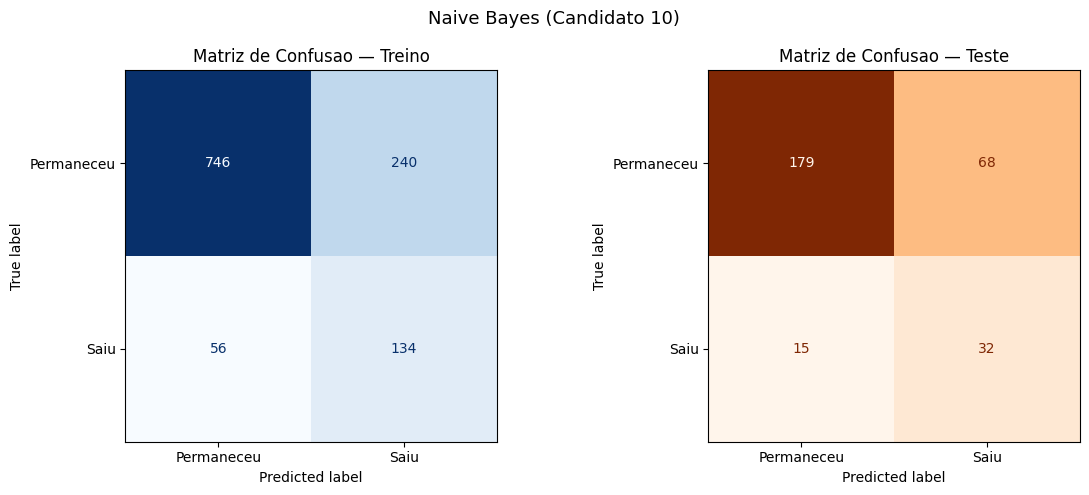

In [111]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Naive Bayes (Candidato 10)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_nb.png", dpi=150, bbox_inches="tight")
plt.show()

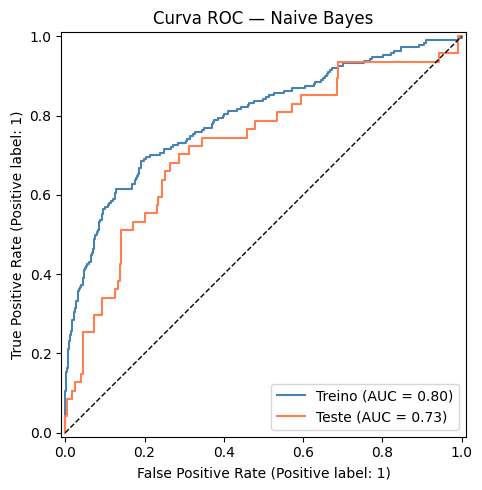

In [112]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Naive Bayes")
plt.tight_layout()
plt.savefig("roc_curve_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [113]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 179  OK
  FP — Permaneceu, previsto Saiu:       68  Erro
  FN — Saiu, previsto Permaneceu:       15  Erro (critico)
  TP — Saiu, previsto Saiu:             32  OK

  O modelo falhou em detetar 15 saidas reais (Falsos Negativos).


In [114]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 10")
print("=" * 55)
print(f"  Algoritmo:         Naive Bayes (GaussianNB)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 10
  Algoritmo:         Naive Bayes (GaussianNB)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.4752
  F1 teste:  0.4354
  Baseline:  0.3273
  Melhoria:  +0.1081


## CANDIDATO 11 — K-Nearest Neighbors (KNN)

In [115]:
# 1. IMPORTAÇÕES
from sklearn.neighbors import KNeighborsClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [116]:
# 2. TREINO DO MODELO
# Pipeline com normalização (KNN é sensível à escala)
# Pipeline: normaliza primeiro (KNN é muito sensível à escala) e depois aplica KNN
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    KNeighborsClassifier())  # k=5 vizinhos por default
])
# Treina o Pipeline
pipeline_knn.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  K (vizinhos): {pipeline_knn.named_steps['clf'].n_neighbors}")

Modelo treinado.
  K (vizinhos): 5


In [117]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = pipeline_knn.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = pipeline_knn.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.4223
  Precision: 0.8689
  Recall:    0.2789
  AUC-ROC:   0.9163

              precision    recall  f1-score   support

  Permaneceu       0.88      0.99      0.93       986
        Saiu       0.87      0.28      0.42       190

    accuracy                           0.88      1176
   macro avg       0.87      0.64      0.68      1176
weighted avg       0.88      0.88      0.85      1176



In [118]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = pipeline_knn.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = pipeline_knn.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.1724
  Precision: 0.4545
  Recall:    0.1064
  AUC-ROC:   0.6464

              precision    recall  f1-score   support

  Permaneceu       0.85      0.98      0.91       247
        Saiu       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



In [119]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_knn = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_knn)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.4223,0.8689,0.2789,0.9163
1,Teste,0.1724,0.4545,0.1064,0.6464



  Diferenca F1 (treino - teste): 0.2499
  --> Sinal de OVERFITTING.


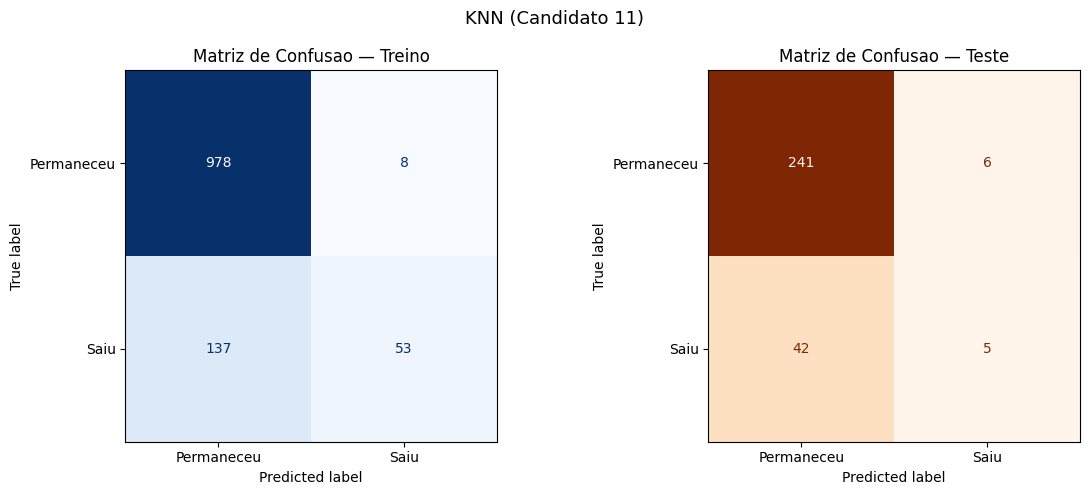

In [120]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("KNN (Candidato 11)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_knn.png", dpi=150, bbox_inches="tight")
plt.show()

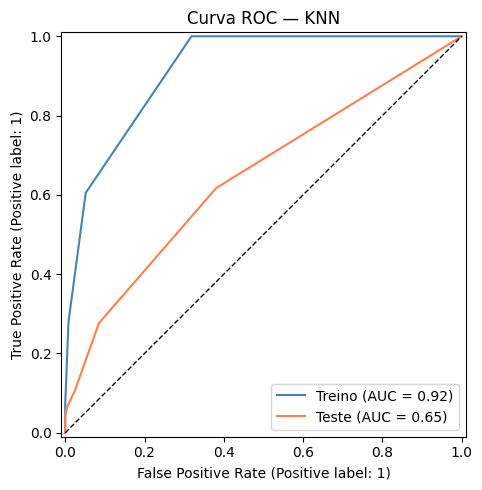

In [121]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — KNN")
plt.tight_layout()
plt.savefig("roc_curve_knn.png", dpi=150, bbox_inches="tight")
plt.show()

In [122]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 241  OK
  FP — Permaneceu, previsto Saiu:       6  Erro
  FN — Saiu, previsto Permaneceu:       42  Erro (critico)
  TP — Saiu, previsto Saiu:             5  OK

  O modelo falhou em detetar 42 saidas reais (Falsos Negativos).


In [123]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 11")
print("=" * 55)
print(f"  Algoritmo:         K-Nearest Neighbors")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 11
  Algoritmo:         K-Nearest Neighbors
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.4223
  F1 teste:  0.1724
  Baseline:  0.3273
  Melhoria:  -0.1549


## CANDIDATO 12 — Extra Trees

In [124]:
# 1. IMPORTAÇÕES
from sklearn.ensemble import ExtraTreesClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [125]:
# 2. TREINO DO MODELO
# Extra Trees: similar ao Random Forest mas os cortes das árvores são completamente aleatórios
# Ainda mais rápido que RF e frequentemente comparável em desempenho
clf_et = ExtraTreesClassifier(random_state=42)
# Treina o conjunto de árvores aleatórias
clf_et.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Numero de arvores: {clf_et.n_estimators}")

Modelo treinado.
  Numero de arvores: 100


In [126]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_et.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_et.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [127]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_et.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_et.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.2143
  Precision: 0.6667
  Recall:    0.1277
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.86      0.99      0.92       247
        Saiu       0.67      0.13      0.21        47

    accuracy                           0.85       294
   macro avg       0.76      0.56      0.57       294
weighted avg       0.83      0.85      0.80       294



In [128]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_et = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_et)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.2143,0.6667,0.1277,0.8099



  Diferenca F1 (treino - teste): 0.7857
  --> Sinal de OVERFITTING.


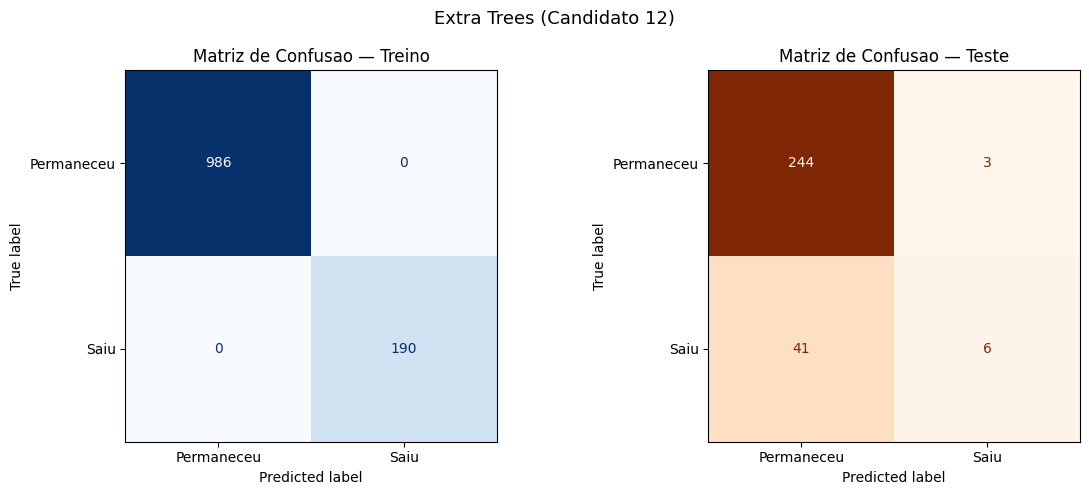

In [129]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Extra Trees (Candidato 12)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_et.png", dpi=150, bbox_inches="tight")
plt.show()

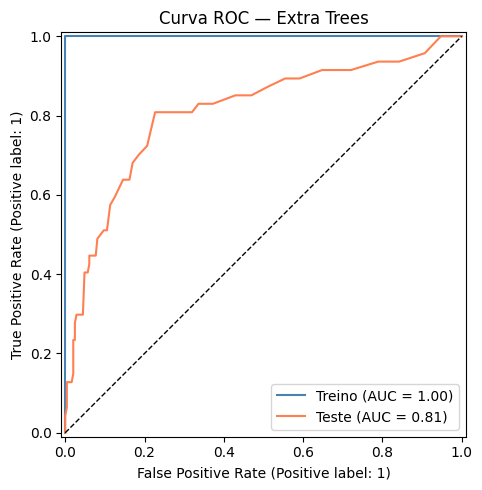

In [130]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Extra Trees")
plt.tight_layout()
plt.savefig("roc_curve_et.png", dpi=150, bbox_inches="tight")
plt.show()

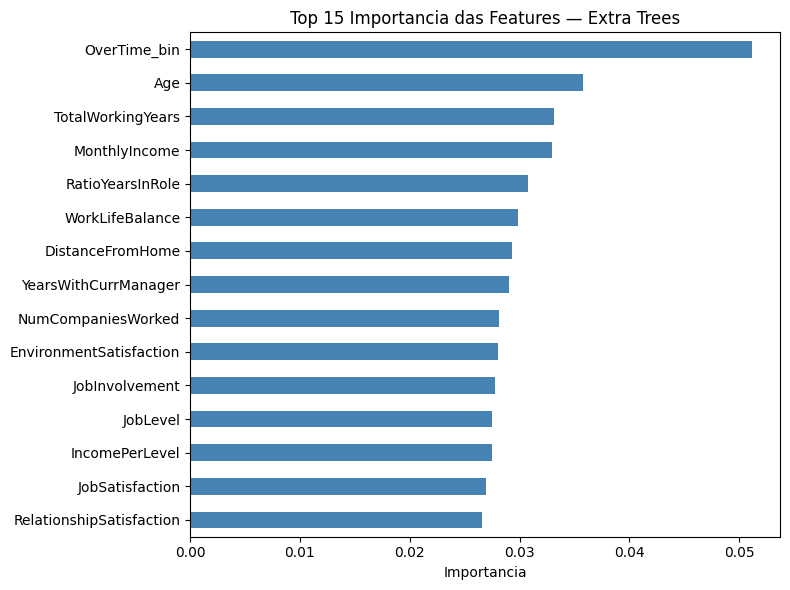

In [131]:
# 6.3 VISUALIZAÇÃO — Top 15 Importância das Features
feat_imp_et = pd.Series(clf_et.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_et.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Importancia das Features — Extra Trees")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_et.png", dpi=150, bbox_inches="tight")
plt.show()

In [132]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 244  OK
  FP — Permaneceu, previsto Saiu:       3  Erro
  FN — Saiu, previsto Permaneceu:       41  Erro (critico)
  TP — Saiu, previsto Saiu:             6  OK

  O modelo falhou em detetar 41 saidas reais (Falsos Negativos).


In [133]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 12")
print("=" * 55)
print(f"  Algoritmo:         Extra Trees")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Nenhuma")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 12
  Algoritmo:         Extra Trees
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Nenhuma
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.2143
  Baseline:  0.3273
  Melhoria:  -0.1130


## CANDIDATO 13 — Rede Neuronal MLP (sklearn)

In [134]:
# 1. IMPORTAÇÕES
from sklearn.neural_network import MLPClassifier
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [135]:
# 2. TREINO DO MODELO
# Pipeline com normalização (redes neuronais são sensíveis à escala)
# Pipeline: normaliza os dados (essencial para redes neuronais) e aplica MLP
pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    MLPClassifier(random_state=42))  # Arquitetura default: 1 camada oculta com 100 neurónios
])
# Treina a rede neuronal
pipeline_mlp.fit(X_train, y_train)
print("Modelo treinado.")
print(f"  Camadas ocultas: {pipeline_mlp.named_steps['clf'].hidden_layer_sizes}")
print(f"  Iteracoes:       {pipeline_mlp.named_steps['clf'].n_iter_}")

Modelo treinado.
  Camadas ocultas: (100,)
  Iteracoes:       200


In [136]:
# 3. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = pipeline_mlp.predict(X_train)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = pipeline_mlp.predict_proba(X_train)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train):.4f}")
print()
print(classification_report(y_train, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [137]:
# 4. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = pipeline_mlp.predict(X_test)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = pipeline_mlp.predict_proba(X_test)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4634
  Precision: 0.5429
  Recall:    0.4043
  AUC-ROC:   0.7414

              precision    recall  f1-score   support

  Permaneceu       0.89      0.94      0.91       247
        Saiu       0.54      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.72      0.67      0.69       294
weighted avg       0.84      0.85      0.84       294



In [138]:
# 5. TABELA COMPARATIVA TREINO vs TESTE
resultados_mlp = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train),        f1_score(y_test, y_pred_test)],
    "Precision": [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
    "Recall":    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train),  roc_auc_score(y_test, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_mlp)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.0000,1.0000,1.0000,1.0000
1,Teste,0.4634,0.5429,0.4043,0.7414



  Diferenca F1 (treino - teste): 0.5366
  --> Sinal de OVERFITTING.


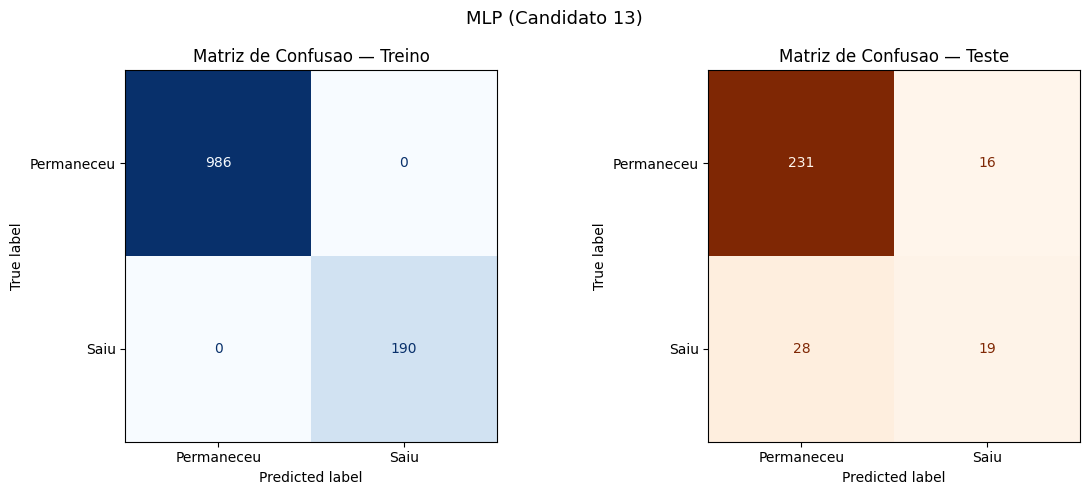

In [139]:
# 6.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("MLP (Candidato 13)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

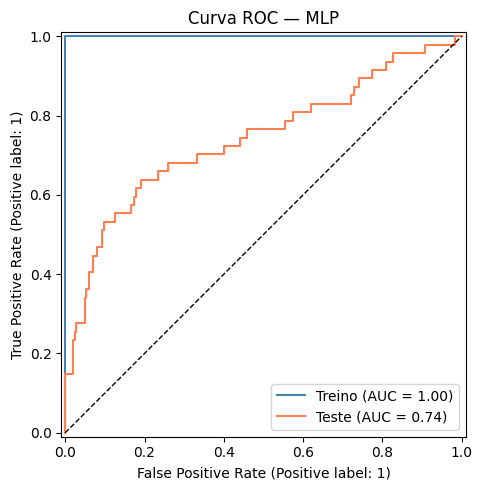

In [140]:
# 6.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — MLP")
plt.tight_layout()
plt.savefig("roc_curve_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

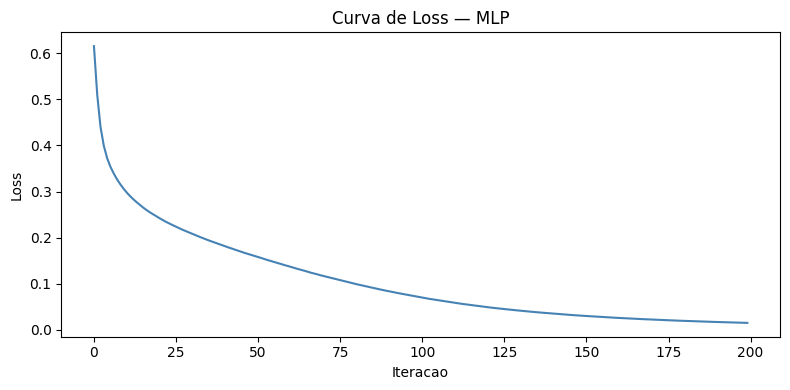

In [141]:
# 6.3 VISUALIZAÇÃO — Curva de Aprendizagem (loss durante treino)
mlp_model = pipeline_mlp.named_steps["clf"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_model.loss_curve_, color="steelblue")
ax.set_title("Curva de Loss — MLP")
ax.set_xlabel("Iteracao")
ax.set_ylabel("Loss")
plt.tight_layout()
plt.savefig("loss_curve_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

In [142]:
# 7. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 231  OK
  FP — Permaneceu, previsto Saiu:       16  Erro
  FN — Saiu, previsto Permaneceu:       28  Erro (critico)
  TP — Saiu, previsto Saiu:             19  OK

  O modelo falhou em detetar 28 saidas reais (Falsos Negativos).


In [143]:
# 8. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 13")
print("=" * 55)
print(f"  Algoritmo:         Rede Neuronal MLP (sklearn)")
print(f"  Arquitetura:       {pipeline_mlp.named_steps['clf'].hidden_layer_sizes} (default)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 13
  Algoritmo:         Rede Neuronal MLP (sklearn)
  Arquitetura:       (100,) (default)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.4634
  Baseline:  0.3273
  Melhoria:  +0.1361


## CANDIDATO 14 — Rede Neuronal TabNet (pytorch-tabnet)

In [144]:
# 1. INSTALAÇÃO E IMPORTAÇÕES
import subprocess
subprocess.run(["pip", "install", "pytorch-tabnet", "-q"], check=True)

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print("Bibliotecas importadas com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.2 MB/s eta 0:00:00
Bibliotecas importadas com sucesso.


In [145]:
# 2. PREPARAÇÃO DOS DADOS (TabNet requer numpy float32)
scaler_tab = SS()
X_train_tab = scaler_tab.fit_transform(X_train).astype(np.float32)
X_test_tab  = scaler_tab.transform(X_test).astype(np.float32)
y_train_tab = y_train.values.reshape(-1)
y_test_tab  = y_test.values.reshape(-1)
print(f"X_train_tab shape: {X_train_tab.shape}")
print(f"X_test_tab shape:  {X_test_tab.shape}")

X_train_tab shape: (1176, 53)
X_test_tab shape:  (294, 53)


In [146]:
# 3. TREINO DO MODELO
# TabNetClassifier com parâmetros default
clf_tabnet = TabNetClassifier(verbose=0, seed=42)
clf_tabnet.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    eval_metric=["auc"],
    batch_size=256,
    virtual_batch_size=128,
    max_epochs=100,
    patience=15,
)
print("Modelo treinado.")
print(f"  Melhor epoca: {clf_tabnet.best_epoch}")


Early stopping occurred at epoch 50 with best_epoch = 35 and best_val_0_auc = 0.7669
Modelo treinado.
  Melhor epoca: 35


In [147]:
# 4. MÉTRICAS NO TREINO
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = clf_tabnet.predict(X_train_tab)
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = clf_tabnet.predict_proba(X_train_tab)[:, 1]
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_tab, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train_tab, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train_tab, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_tab, y_proba_train):.4f}")
print()
print(classification_report(y_train_tab, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.7301
  Precision: 0.8750
  Recall:    0.6263
  AUC-ROC:   0.9492

              precision    recall  f1-score   support

  Permaneceu       0.93      0.98      0.96       986
        Saiu       0.88      0.63      0.73       190

    accuracy                           0.93      1176
   macro avg       0.90      0.80      0.84      1176
weighted avg       0.92      0.93      0.92      1176



In [148]:
# 5. MÉTRICAS NO TESTE
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = clf_tabnet.predict(X_test_tab)
# Probabilidades da classe positiva para os dados de teste
y_proba_test = clf_tabnet.predict_proba(X_test_tab)[:, 1]
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_tab, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test_tab, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test_tab, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_tab, y_proba_test):.4f}")
print()
print(classification_report(y_test_tab, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.3733
  Precision: 0.5000
  Recall:    0.2979
  AUC-ROC:   0.7669

              precision    recall  f1-score   support

  Permaneceu       0.88      0.94      0.91       247
        Saiu       0.50      0.30      0.37        47

    accuracy                           0.84       294
   macro avg       0.69      0.62      0.64       294
weighted avg       0.82      0.84      0.82       294



In [149]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_tabnet = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_tab, y_pred_train),        f1_score(y_test_tab, y_pred_test)],
    "Precision": [precision_score(y_train_tab, y_pred_train), precision_score(y_test_tab, y_pred_test)],
    "Recall":    [recall_score(y_train_tab, y_pred_train),    recall_score(y_test_tab, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train_tab, y_proba_train),  roc_auc_score(y_test_tab, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_tabnet)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train_tab, y_pred_train) - f1_score(y_test_tab, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.7301,0.875,0.6263,0.9492
1,Teste,0.3733,0.500,0.2979,0.7669



  Diferenca F1 (treino - teste): 0.3567
  --> Sinal de OVERFITTING.


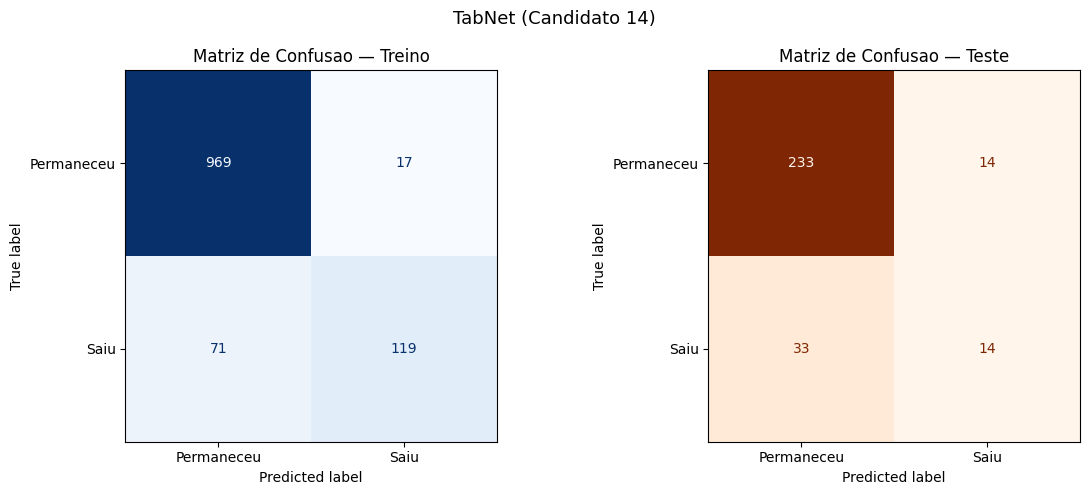

In [150]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_tab, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_tab, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("TabNet (Candidato 14)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

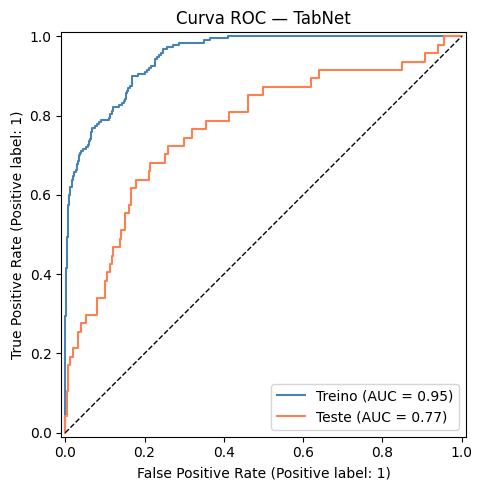

In [151]:
# 7.2 VISUALIZAÇÃO — Curva ROC
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_tab, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_tab,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — TabNet")
plt.tight_layout()
plt.savefig("roc_curve_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

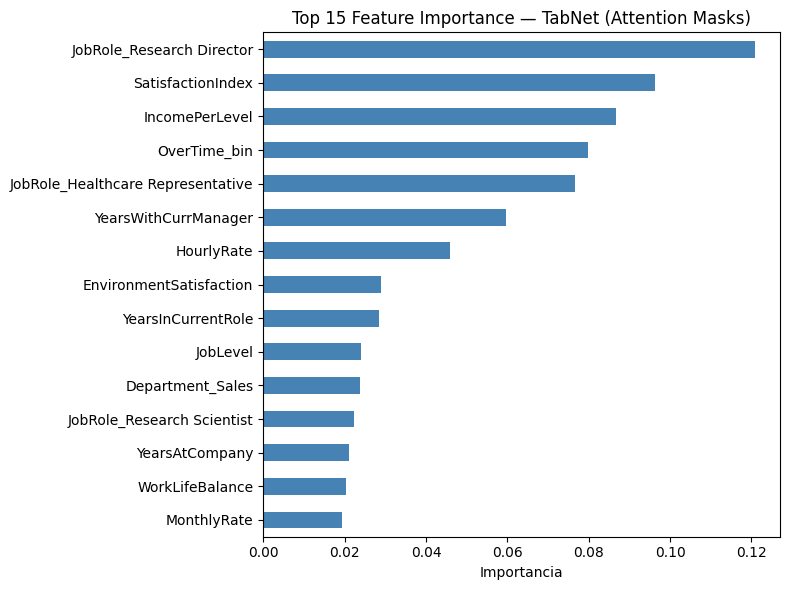

In [152]:
# 7.3 VISUALIZAÇÃO — Feature Importance (TabNet Masks)
feat_imp_tabnet = pd.Series(
    clf_tabnet.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_tabnet.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Feature Importance — TabNet (Attention Masks)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("feature_importance_tabnet.png", dpi=150, bbox_inches="tight")
plt.show()

In [153]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test_tab, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 233  OK
  FP — Permaneceu, previsto Saiu:       14  Erro
  FN — Saiu, previsto Permaneceu:       33  Erro (critico)
  TP — Saiu, previsto Saiu:             14  OK

  O modelo falhou em detetar 33 saidas reais (Falsos Negativos).


In [154]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 14")
print("=" * 55)
print(f"  Algoritmo:         TabNet (Rede Neuronal para dados tabulares)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_tab, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test_tab, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test_tab, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 14
  Algoritmo:         TabNet (Rede Neuronal para dados tabulares)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.7301
  F1 teste:  0.3733
  Baseline:  0.3273
  Melhoria:  +0.0461


## CANDIDATO 15 — Rede Neuronal Keras

In [155]:
# 1. INSTALAÇÃO E IMPORTAÇÕES
import subprocess
subprocess.run(["pip", "install", "tensorflow", "-q"], check=True)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print(f"TensorFlow versão: {tf.__version__}")
print("Bibliotecas importadas com sucesso.")

2026-05-15 15:05:54.855429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778857555.070744      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778857555.134277      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778857555.666327      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778857555.666364      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778857555.666367      16 computation_placer.cc:177] computation placer alr

TensorFlow versão: 2.19.0
Bibliotecas importadas com sucesso.


In [156]:
# 2. PREPARAÇÃO DOS DADOS
scaler_keras = SS()
X_train_keras = scaler_keras.fit_transform(X_train).astype(np.float32)
X_test_keras  = scaler_keras.transform(X_test).astype(np.float32)
y_train_keras = y_train.values.astype(np.float32)
y_test_keras  = y_test.values.astype(np.float32)
print(f"X_train_keras shape: {X_train_keras.shape}")
print(f"X_test_keras shape:  {X_test_keras.shape}")

X_train_keras shape: (1176, 53)
X_test_keras shape:  (294, 53)


In [157]:
# 3. TREINO DO MODELO
# Arquitetura default simples: 2 camadas ocultas (64, 32) + sigmoid
tf.random.set_seed(42)

model_keras = keras.Sequential([
    layers.Input(shape=(X_train_keras.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
])

model_keras.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

model_keras.summary()

history_keras = model_keras.fit(
    X_train_keras, y_train_keras,
    validation_data=(X_test_keras, y_test_keras),
    epochs=100,
    batch_size=32,
    verbose=0,
)
print("Modelo treinado.")
print(f"  Épocas treinadas: {len(history_keras.history['loss'])}")

2026-05-15 15:06:20.417449: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

Modelo treinado.
  Épocas treinadas: 100


In [158]:
# 4. MÉTRICAS NO TREINO
# Gera as probabilidades da classe positiva (usado para AUC-ROC)
y_proba_train = model_keras.predict(X_train_keras, verbose=0).flatten()
# Gera as previsões binárias (0 ou 1) para os dados de treino
y_pred_train  = (y_proba_train >= 0.5).astype(int)
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_keras, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train_keras, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train_keras, y_pred_train):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_keras, y_proba_train):.4f}")
print()
print(classification_report(y_train_keras, y_pred_train, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [159]:
# 5. MÉTRICAS NO TESTE
# Probabilidades da classe positiva para os dados de teste
y_proba_test = model_keras.predict(X_test_keras, verbose=0).flatten()
# Gera as previsões binárias para os dados de teste (dados que o modelo nunca viu)
y_pred_test  = (y_proba_test >= 0.5).astype(int)
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_keras, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test_keras, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test_keras, y_pred_test):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_keras, y_proba_test):.4f}")
print()
print(classification_report(y_test_keras, y_pred_test, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4270
  Precision: 0.4524
  Recall:    0.4043
  AUC-ROC:   0.7364

              precision    recall  f1-score   support

  Permaneceu       0.89      0.91      0.90       247
        Saiu       0.45      0.40      0.43        47

    accuracy                           0.83       294
   macro avg       0.67      0.66      0.66       294
weighted avg       0.82      0.83      0.82       294



In [160]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_keras = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_keras, y_pred_train),        f1_score(y_test_keras, y_pred_test)],
    "Precision": [precision_score(y_train_keras, y_pred_train), precision_score(y_test_keras, y_pred_test)],
    "Recall":    [recall_score(y_train_keras, y_pred_train),    recall_score(y_test_keras, y_pred_test)],
    "AUC-ROC":   [roc_auc_score(y_train_keras, y_proba_train),  roc_auc_score(y_test_keras, y_proba_test)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_keras)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train_keras, y_pred_train) - f1_score(y_test_keras, y_pred_test)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,1.000,1.0000,1.0000,1.0000
1,Teste,0.427,0.4524,0.4043,0.7364



  Diferenca F1 (treino - teste): 0.5730
  --> Sinal de OVERFITTING.


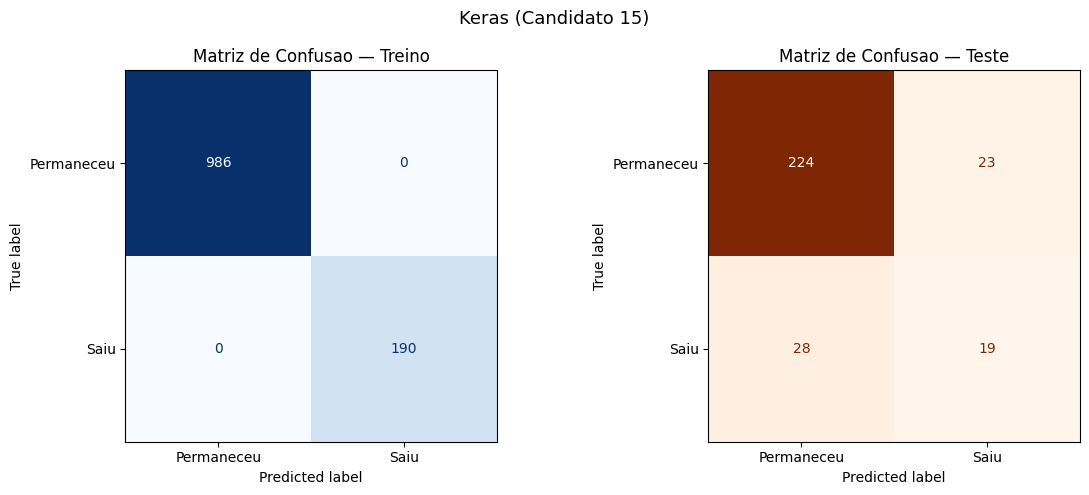

In [161]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_keras, y_pred_train), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_keras, y_pred_test), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Keras (Candidato 15)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_keras.png", dpi=150, bbox_inches="tight")
plt.show()

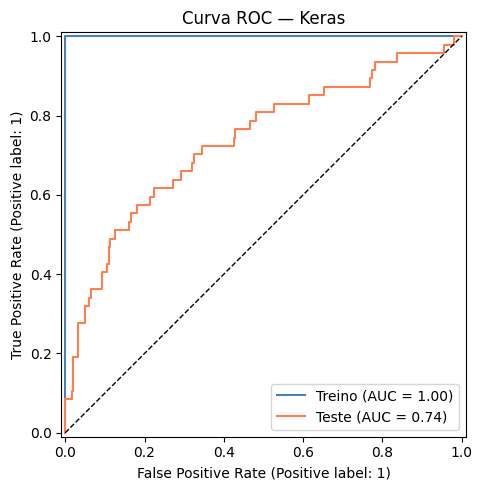

In [162]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_keras, y_proba_train, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_keras,  y_proba_test,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Keras")
plt.tight_layout()
plt.savefig("roc_curve_keras.png", dpi=150, bbox_inches="tight")
plt.show()

Chaves disponíveis: ['AUC', 'loss', 'val_AUC', 'val_loss']
  auc_key:     AUC
  val_auc_key: val_AUC


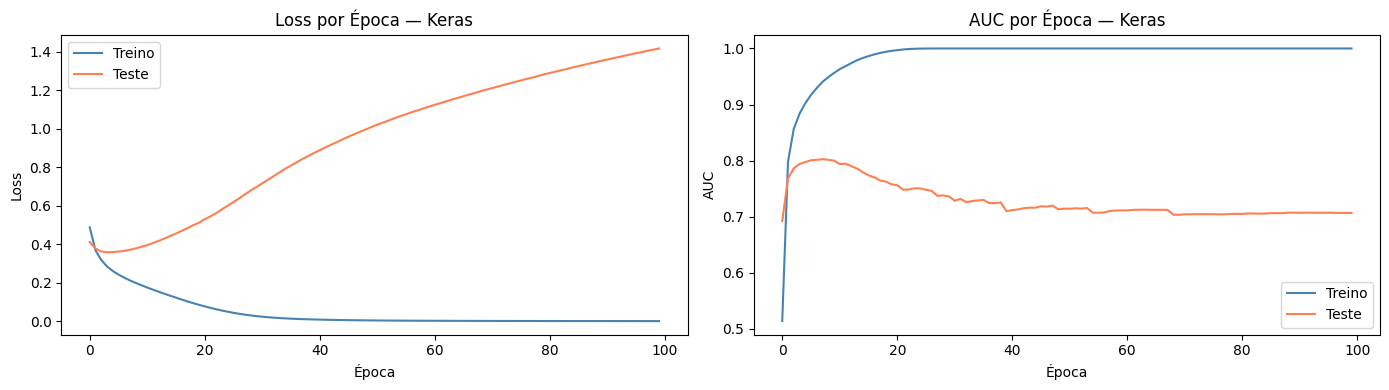

In [163]:
# 7.3 VISUALIZAÇÃO — Curvas de Loss e AUC durante treino
# Detectar a chave do AUC de forma robusta (case-insensitive)
all_keys    = list(history_keras.history.keys())
auc_key     = next((k for k in all_keys if "auc" in k.lower() and not k.lower().startswith("val_")), None)
val_auc_key = next((k for k in all_keys if "auc" in k.lower() and k.lower().startswith("val_")), None)

print(f"Chaves disponíveis: {all_keys}")
print(f"  auc_key:     {auc_key}")
print(f"  val_auc_key: {val_auc_key}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_keras.history["loss"],     label="Treino", color="steelblue")
axes[0].plot(history_keras.history["val_loss"], label="Teste",  color="coral")
axes[0].set_title("Loss por Época — Keras")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

if auc_key and val_auc_key:
    axes[1].plot(history_keras.history[auc_key],     label="Treino", color="steelblue")
    axes[1].plot(history_keras.history[val_auc_key], label="Teste",  color="coral")
    axes[1].set_title(f"AUC por Época — Keras")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Metrica AUC nao encontrada no history",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("AUC por Época — Keras")

plt.tight_layout()
plt.savefig("history_keras.png", dpi=150, bbox_inches="tight")
plt.show()

In [164]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test_keras, y_pred_test).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 224  OK
  FP — Permaneceu, previsto Saiu:       23  Erro
  FN — Saiu, previsto Permaneceu:       28  Erro (critico)
  TP — Saiu, previsto Saiu:             19  OK

  O modelo falhou em detetar 28 saidas reais (Falsos Negativos).


In [165]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 15")
print("=" * 55)
print(f"  Algoritmo:         Rede Neuronal Keras (TensorFlow)")
print(f"  Arquitetura:       Input -> Dense(64,relu) -> Dense(32,relu) -> Dense(1,sigmoid)")
print(f"  Features:          {X_train_keras.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_keras, y_pred_train):.4f}")
print(f"  F1 teste:  {f1_score(y_test_keras, y_pred_test):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test_keras, y_pred_test) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 15
  Algoritmo:         Rede Neuronal Keras (TensorFlow)
  Arquitetura:       Input -> Dense(64,relu) -> Dense(32,relu) -> Dense(1,sigmoid)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 1.0000
  F1 teste:  0.4270
  Baseline:  0.3273
  Melhoria:  +0.0997


## CANDIDATO 16 — Keras com Dropout + BatchNormalization

In [166]:
# 1. IMPORTAÇÕES
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler as SS
import numpy as np
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [167]:
# 2. PREPARAÇÃO DOS DADOS
scaler_k16 = SS()
X_train_k16 = scaler_k16.fit_transform(X_train).astype(np.float32)
X_test_k16  = scaler_k16.transform(X_test).astype(np.float32)
y_train_k16 = y_train.values.astype(np.float32)
y_test_k16  = y_test.values.astype(np.float32)
print(f"X_train_k16 shape: {X_train_k16.shape}")
print(f"X_test_k16 shape:  {X_test_k16.shape}")

X_train_k16 shape: (1176, 53)
X_test_k16 shape:  (294, 53)


In [168]:
# 3. TREINO DO MODELO
# Arquitetura com Dropout e BatchNormalization para regularização
tf.random.set_seed(42)
model_k16 = keras.Sequential([
    layers.Input(shape=(X_train_k16.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model_k16.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
model_k16.summary()
history_k16 = model_k16.fit(
    X_train_k16, y_train_k16,
    validation_data=(X_test_k16, y_test_k16),
    epochs=100, batch_size=32, verbose=0,
)
print("Modelo treinado.")
print(f"  Epocas treinadas: {len(history_k16.history['loss'])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,049 (70.50 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 384 (1.50 KB)

Modelo treinado.
  Epocas treinadas: 100


In [169]:
# 4. MÉTRICAS NO TREINO
y_proba_train_k16 = model_k16.predict(X_train_k16, verbose=0).flatten()
y_pred_train_k16  = (y_proba_train_k16 >= 0.5).astype(int)
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  Precision: {precision_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  Recall:    {recall_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train_k16, y_proba_train_k16):.4f}")
print()
print(classification_report(y_train_k16, y_pred_train_k16, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.9974
  Precision: 0.9948
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       0.99      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [170]:
# 5. MÉTRICAS NO TESTE
y_proba_test_k16 = model_k16.predict(X_test_k16, verbose=0).flatten()
y_pred_test_k16  = (y_proba_test_k16 >= 0.5).astype(int)
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Precision: {precision_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Recall:    {recall_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_k16, y_proba_test_k16):.4f}")
print()
print(classification_report(y_test_k16, y_pred_test_k16, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4615
  Precision: 0.4773
  Recall:    0.4468
  AUC-ROC:   0.7340

              precision    recall  f1-score   support

  Permaneceu       0.90      0.91      0.90       247
        Saiu       0.48      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.69      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294



In [171]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_k16 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train_k16, y_pred_train_k16),        f1_score(y_test_k16, y_pred_test_k16)],
    "Precision": [precision_score(y_train_k16, y_pred_train_k16), precision_score(y_test_k16, y_pred_test_k16)],
    "Recall":    [recall_score(y_train_k16, y_pred_train_k16),    recall_score(y_test_k16, y_pred_test_k16)],
    "AUC-ROC":   [roc_auc_score(y_train_k16, y_proba_train_k16),  roc_auc_score(y_test_k16, y_proba_test_k16)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_k16)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train_k16, y_pred_train_k16) - f1_score(y_test_k16, y_pred_test_k16)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.9974,0.9948,1.0000,1.000
1,Teste,0.4615,0.4773,0.4468,0.734



  Diferenca F1 (treino - teste): 0.5358
  --> Sinal de OVERFITTING.


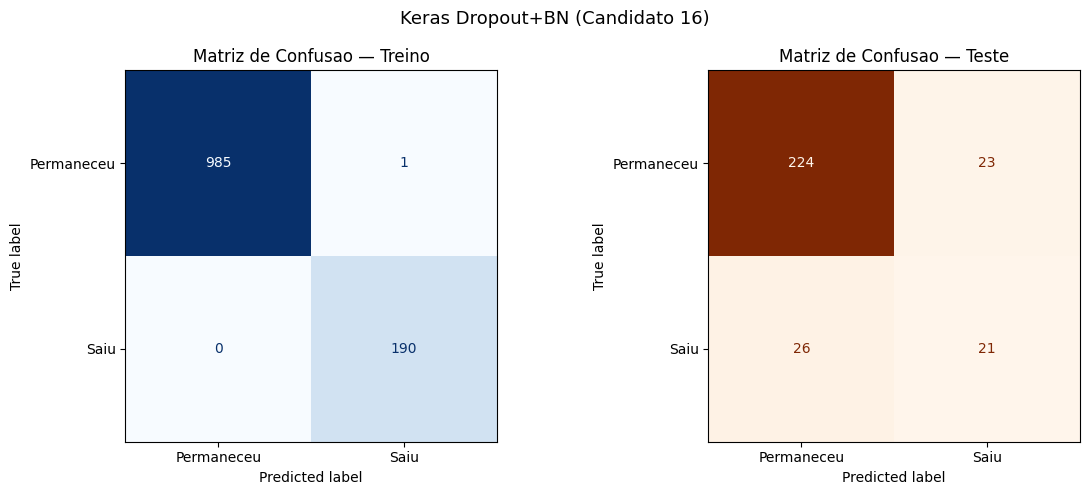

In [172]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train_k16, y_pred_train_k16), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test_k16, y_pred_test_k16), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("Keras Dropout+BN (Candidato 16)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_k16.png", dpi=150, bbox_inches="tight")
plt.show()

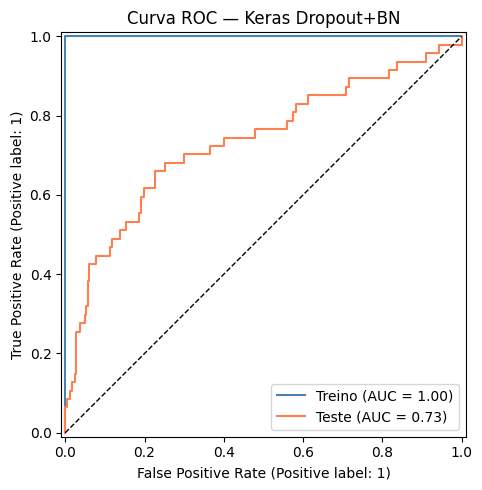

In [173]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train_k16, y_proba_train_k16, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test_k16,  y_proba_test_k16,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Keras Dropout+BN")
plt.tight_layout()
plt.savefig("roc_curve_k16.png", dpi=150, bbox_inches="tight")
plt.show()

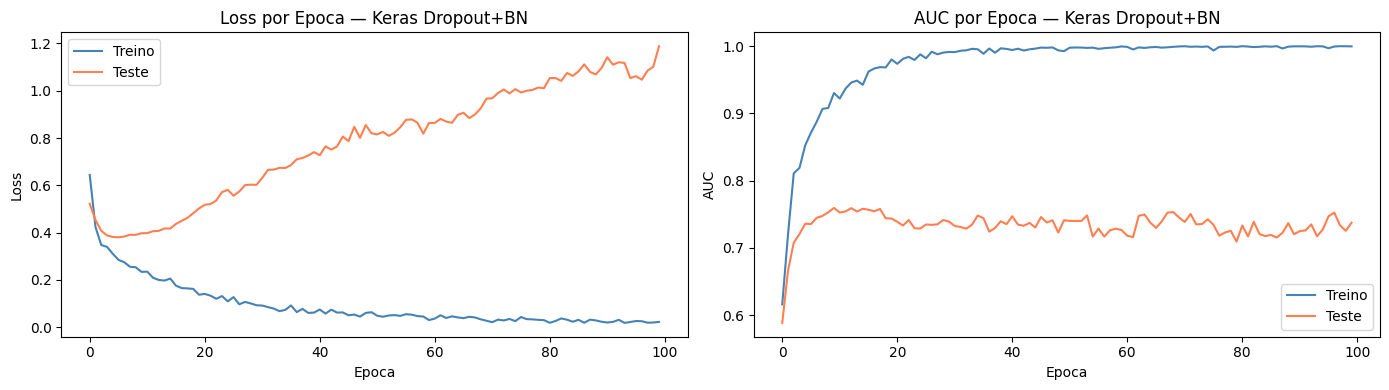

In [174]:
# 7.3 VISUALIZAÇÃO — Curvas de Loss e AUC durante treino
all_keys    = list(history_k16.history.keys())
auc_key     = next((k for k in all_keys if "auc" in k.lower() and not k.lower().startswith("val_")), None)
val_auc_key = next((k for k in all_keys if "auc" in k.lower() and k.lower().startswith("val_")), None)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_k16.history["loss"], label="Treino", color="steelblue")
axes[0].plot(history_k16.history["val_loss"], label="Teste", color="coral")
axes[0].set_title("Loss por Epoca — Keras Dropout+BN")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend()
if auc_key and val_auc_key:
    axes[1].plot(history_k16.history[auc_key], label="Treino", color="steelblue")
    axes[1].plot(history_k16.history[val_auc_key], label="Teste", color="coral")
    axes[1].set_title("AUC por Epoca — Keras Dropout+BN")
    axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("AUC"); axes[1].legend()
plt.tight_layout()
plt.savefig("history_k16.png", dpi=150, bbox_inches="tight")
plt.show()

In [175]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test_k16, y_pred_test_k16).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 224  OK
  FP — Permaneceu, previsto Saiu:       23  Erro
  FN — Saiu, previsto Permaneceu:       26  Erro (critico)
  TP — Saiu, previsto Saiu:             21  OK

  O modelo falhou em detetar 26 saidas reais (Falsos Negativos).


In [176]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 16")
print("=" * 55)
print(f"  Algoritmo:         Keras com Dropout + BatchNormalization")
print(f"  Arquitetura:       128->BN->Drop(0.3)->64->BN->Drop(0.3)->32->1")
print(f"  Features:          {X_train_k16.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      StandardScaler")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train_k16, y_pred_train_k16):.4f}")
print(f"  F1 teste:  {f1_score(y_test_k16, y_pred_test_k16):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test_k16, y_pred_test_k16) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 16
  Algoritmo:         Keras com Dropout + BatchNormalization
  Arquitetura:       128->BN->Drop(0.3)->64->BN->Drop(0.3)->32->1
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      StandardScaler
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.9974
  F1 teste:  0.4615
  Baseline:  0.3273
  Melhoria:  +0.1343


## CANDIDATO 17 — GANDALF (pytorch-tabular)

In [177]:
# 1. INSTALAÇÃO E IMPORTAÇÕES
import subprocess
subprocess.run(["pip", "install", "pytorch-tabular", "-q"], check=True)

from pytorch_tabular import TabularModel
from pytorch_tabular.models import GANDALFConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import pandas as pd
print("Bibliotecas importadas com sucesso.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.0 MB/s eta 0:00:00
Bibliotecas importadas com sucesso.


In [178]:
# 2. PREPARAÇÃO DOS DADOS (pytorch-tabular usa DataFrames)
feature_cols = X_train.columns.tolist()
TARGET_COL   = "Attrition_bin"

df_train_g17 = X_train.copy(); df_train_g17[TARGET_COL] = y_train.values
df_test_g17  = X_test.copy();  df_test_g17[TARGET_COL]  = y_test.values
print(f"df_train_g17 shape: {df_train_g17.shape}")
print(f"df_test_g17 shape:  {df_test_g17.shape}")

df_train_g17 shape: (1176, 54)
df_test_g17 shape:  (294, 54)


In [179]:
# 3. TREINO DO MODELO
data_config_g17 = DataConfig(
    target=[TARGET_COL],
    continuous_cols=feature_cols,
    categorical_cols=[],
)
trainer_config_g17 = TrainerConfig(
    max_epochs=50,
    batch_size=256,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    checkpoints=None,
    load_best=True,
    progress_bar="none",
    trainer_kwargs={"enable_model_summary": False},
)
model_config_g17 = GANDALFConfig(task="classification")

tabular_gandalf = TabularModel(
    data_config=data_config_g17,
    model_config=model_config_g17,
    optimizer_config=OptimizerConfig(),
    trainer_config=trainer_config_g17,
    verbose=False,
)
tabular_gandalf.fit(train=df_train_g17, validation=df_test_g17)
print("Modelo treinado.")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-15 15:07:32,170 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


Modelo treinado.


In [180]:
# 4. MÉTRICAS NO TREINO
pred_train_g17    = tabular_gandalf.predict(df_train_g17)
y_pred_train_g17  = pred_train_g17["Attrition_bin_prediction"].values
y_proba_train_g17 = pred_train_g17["Attrition_bin_1_probability"].values
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train_g17):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train_g17):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train_g17):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train_g17):.4f}")
print()
print(classification_report(y_train, y_pred_train_g17, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.7645
  Precision: 0.9124
  Recall:    0.6579
  AUC-ROC:   0.9402

              precision    recall  f1-score   support

  Permaneceu       0.94      0.99      0.96       986
        Saiu       0.91      0.66      0.76       190

    accuracy                           0.93      1176
   macro avg       0.92      0.82      0.86      1176
weighted avg       0.93      0.93      0.93      1176



In [181]:
# 5. MÉTRICAS NO TESTE
pred_test_g17    = tabular_gandalf.predict(df_test_g17)
y_pred_test_g17  = pred_test_g17["Attrition_bin_prediction"].values
y_proba_test_g17 = pred_test_g17["Attrition_bin_1_probability"].values
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test_g17):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test_g17):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test_g17):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test_g17):.4f}")
print()
print(classification_report(y_test, y_pred_test_g17, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4938
  Precision: 0.5882
  Recall:    0.4255
  AUC-ROC:   0.7975

              precision    recall  f1-score   support

  Permaneceu       0.90      0.94      0.92       247
        Saiu       0.59      0.43      0.49        47

    accuracy                           0.86       294
   macro avg       0.74      0.68      0.71       294
weighted avg       0.85      0.86      0.85       294



In [182]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_g17 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train_g17),        f1_score(y_test, y_pred_test_g17)],
    "Precision": [precision_score(y_train, y_pred_train_g17), precision_score(y_test, y_pred_test_g17)],
    "Recall":    [recall_score(y_train, y_pred_train_g17),    recall_score(y_test, y_pred_test_g17)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train_g17),  roc_auc_score(y_test, y_proba_test_g17)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_g17)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train_g17) - f1_score(y_test, y_pred_test_g17)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.7645,0.9124,0.6579,0.9402
1,Teste,0.4938,0.5882,0.4255,0.7975



  Diferenca F1 (treino - teste): 0.2707
  --> Sinal de OVERFITTING.


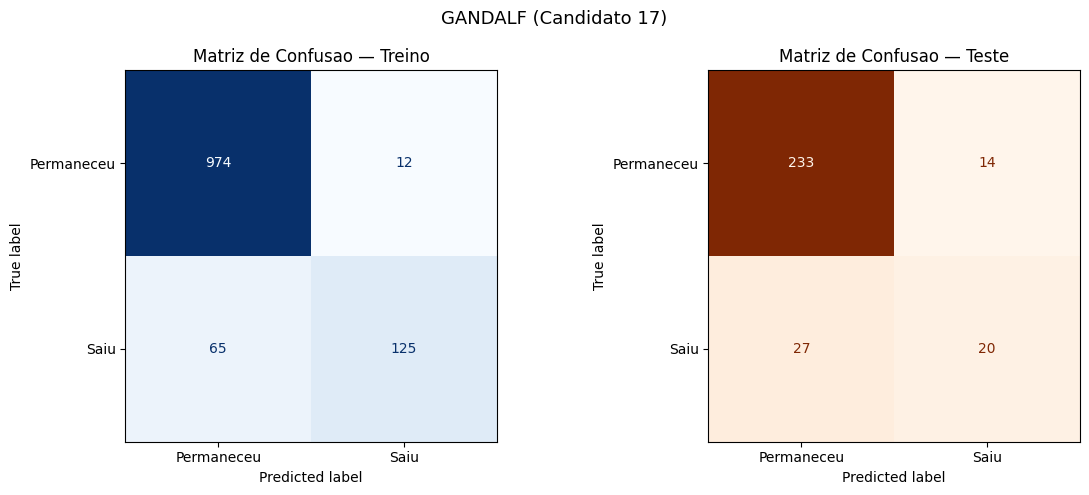

In [183]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train_g17), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test_g17), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("GANDALF (Candidato 17)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_gandalf.png", dpi=150, bbox_inches="tight")
plt.show()

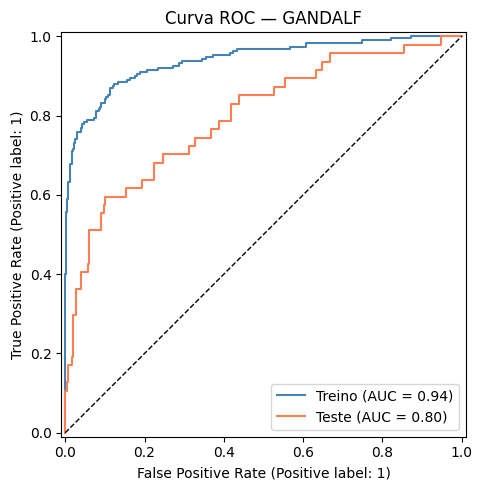

In [184]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train_g17, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test_g17,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — GANDALF")
plt.tight_layout()
plt.savefig("roc_curve_gandalf.png", dpi=150, bbox_inches="tight")
plt.show()

In [185]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_g17).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 233  OK
  FP — Permaneceu, previsto Saiu:       14  Erro
  FN — Saiu, previsto Permaneceu:       27  Erro (critico)
  TP — Saiu, previsto Saiu:             20  OK

  O modelo falhou em detetar 27 saidas reais (Falsos Negativos).


In [186]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 17")
print("=" * 55)
print(f"  Algoritmo:         GANDALF (pytorch-tabular)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Automatica (pytorch-tabular)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train_g17):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test_g17):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test_g17) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 17
  Algoritmo:         GANDALF (pytorch-tabular)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Automatica (pytorch-tabular)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.7645
  F1 teste:  0.4938
  Baseline:  0.3273
  Melhoria:  +0.1666


## CANDIDATO 18 — FT-Transformer (pytorch-tabular)

In [187]:
# 1. IMPORTAÇÕES
from pytorch_tabular.models import FTTransformerConfig
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [188]:
# 2. PREPARAÇÃO DOS DADOS (reutiliza df_train_g17 e df_test_g17)
print(f"df_train shape: {df_train_g17.shape}")
print(f"df_test shape:  {df_test_g17.shape}")

df_train shape: (1176, 54)
df_test shape:  (294, 54)


In [189]:
# 3. TREINO DO MODELO
trainer_config_g18 = TrainerConfig(
    max_epochs=50,
    batch_size=256,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    checkpoints=None,
    load_best=True,
    progress_bar="none",
    trainer_kwargs={"enable_model_summary": False},
)
model_config_g18 = FTTransformerConfig(task="classification")

tabular_ftt = TabularModel(
    data_config=data_config_g17,
    model_config=model_config_g18,
    optimizer_config=OptimizerConfig(),
    trainer_config=trainer_config_g18,
    verbose=False,
)
tabular_ftt.fit(train=df_train_g17, validation=df_test_g17)
print("Modelo treinado.")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-05-15 15:09:57,529 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


Modelo treinado.


In [190]:
# 4. MÉTRICAS NO TREINO
pred_train_g18    = tabular_ftt.predict(df_train_g17)
y_pred_train_g18  = pred_train_g18["Attrition_bin_prediction"].values
y_proba_train_g18 = pred_train_g18["Attrition_bin_1_probability"].values
print("===== METRICAS — TREINO =====")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train_g18):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train_g18):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train_g18):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_train, y_proba_train_g18):.4f}")
print()
print(classification_report(y_train, y_pred_train_g18, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TREINO =====
  F1-Score:  0.6463
  Precision: 0.9135
  Recall:    0.5000
  AUC-ROC:   0.8787

              precision    recall  f1-score   support

  Permaneceu       0.91      0.99      0.95       986
        Saiu       0.91      0.50      0.65       190

    accuracy                           0.91      1176
   macro avg       0.91      0.75      0.80      1176
weighted avg       0.91      0.91      0.90      1176



In [191]:
# 5. MÉTRICAS NO TESTE
pred_test_g18    = tabular_ftt.predict(df_test_g17)
y_pred_test_g18  = pred_test_g18["Attrition_bin_prediction"].values
y_proba_test_g18 = pred_test_g18["Attrition_bin_1_probability"].values
print("===== METRICAS — TESTE =====")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test_g18):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test_g18):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test_g18):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_test_g18):.4f}")
print()
print(classification_report(y_test, y_pred_test_g18, target_names=["Permaneceu", "Saiu"]))

===== METRICAS — TESTE =====
  F1-Score:  0.4789
  Precision: 0.7083
  Recall:    0.3617
  AUC-ROC:   0.8300

              precision    recall  f1-score   support

  Permaneceu       0.89      0.97      0.93       247
        Saiu       0.71      0.36      0.48        47

    accuracy                           0.87       294
   macro avg       0.80      0.67      0.70       294
weighted avg       0.86      0.87      0.86       294



In [192]:
# 6. TABELA COMPARATIVA TREINO vs TESTE
resultados_g18 = pd.DataFrame({
    "Conjunto":  ["Treino", "Teste"],
    "F1-Score":  [f1_score(y_train, y_pred_train_g18),        f1_score(y_test, y_pred_test_g18)],
    "Precision": [precision_score(y_train, y_pred_train_g18), precision_score(y_test, y_pred_test_g18)],
    "Recall":    [recall_score(y_train, y_pred_train_g18),    recall_score(y_test, y_pred_test_g18)],
    "AUC-ROC":   [roc_auc_score(y_train, y_proba_train_g18),  roc_auc_score(y_test, y_proba_test_g18)],
}).round(4)
print("===== TABELA COMPARATIVA TREINO vs TESTE =====")
display(resultados_g18)
# Calcula a diferença de F1 entre treino e teste
# Se > 0.10, o modelo está a decorar o treino (overfitting)
diff = f1_score(y_train, y_pred_train_g18) - f1_score(y_test, y_pred_test_g18)
print(f"\n  Diferenca F1 (treino - teste): {diff:.4f}")
if diff > 0.10:
    print("  --> Sinal de OVERFITTING.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.6463,0.9135,0.5000,0.8787
1,Teste,0.4789,0.7083,0.3617,0.8300



  Diferenca F1 (treino - teste): 0.1674
  --> Sinal de OVERFITTING.


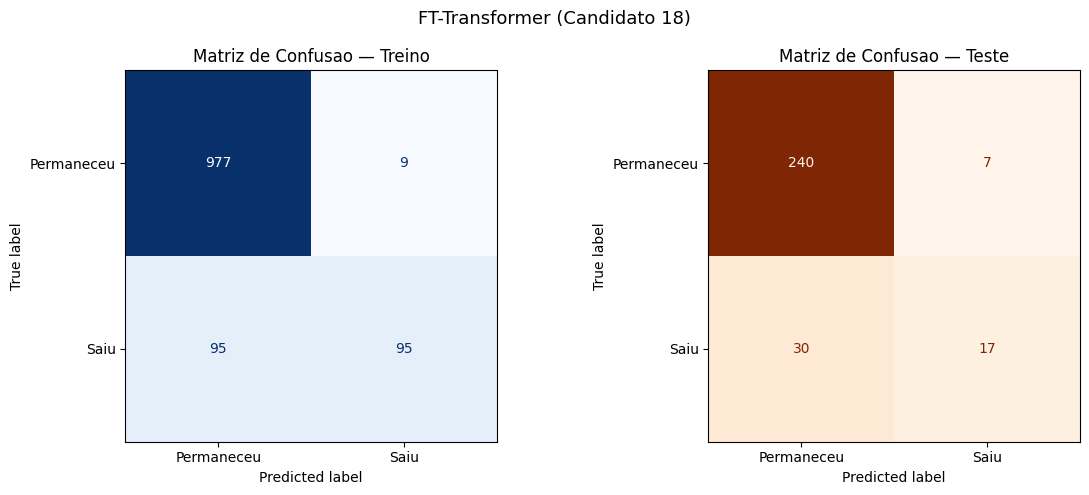

In [193]:
# 7.1 VISUALIZAÇÃO — Matrizes de Confusão (Treino e Teste)
# Cria dois gráficos lado a lado: um para treino e outro para teste
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train_g18), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao — Treino")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test_g18), display_labels=["Permaneceu", "Saiu"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Matriz de Confusao — Teste")
fig.suptitle("FT-Transformer (Candidato 18)", fontsize=13)
plt.tight_layout()
# Guarda o gráfico em ficheiro PNG
plt.savefig("confusion_matrix_ftt.png", dpi=150, bbox_inches="tight")
plt.show()

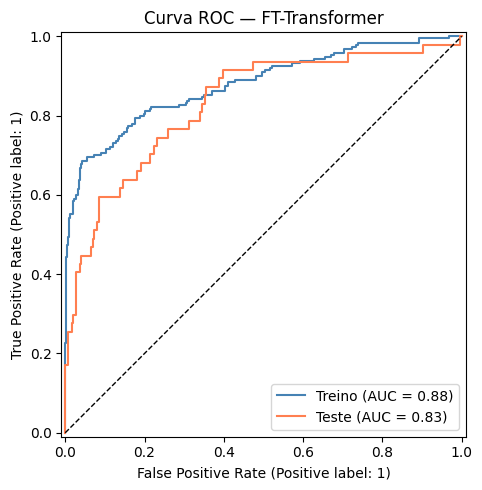

In [194]:
# 7.2 VISUALIZAÇÃO — Curva ROC (Treino e Teste)
# A curva ROC mostra o trade-off entre sensibilidade e especificidade
# Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_train, y_proba_train_g18, name="Treino", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test,  y_proba_test_g18,  name="Teste",  ax=ax, color="coral")
# Linha diagonal: representa um classificador aleatório (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — FT-Transformer")
plt.tight_layout()
plt.savefig("roc_curve_ftt.png", dpi=150, bbox_inches="tight")
plt.show()

In [195]:
# 8. ANÁLISE DA MATRIZ DE CONFUSÃO (TESTE)
# Descompõe a matriz de confusão nos 4 valores:
# TN=acertou permanência, FP=falso alarme, FN=deixou escapar (crítico!), TP=detetou saída corretamente
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test_g18).ravel()
print("===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====")
print(f"  TN — Permaneceu, previsto Permaneceu: {tn}  OK")
print(f"  FP — Permaneceu, previsto Saiu:       {fp}  Erro")
print(f"  FN — Saiu, previsto Permaneceu:       {fn}  Erro (critico)")
print(f"  TP — Saiu, previsto Saiu:             {tp}  OK")
print(f"\n  O modelo falhou em detetar {fn} saidas reais (Falsos Negativos).")

===== ANALISE DA MATRIZ DE CONFUSAO (teste) =====
  TN — Permaneceu, previsto Permaneceu: 240  OK
  FP — Permaneceu, previsto Saiu:       7  Erro
  FN — Saiu, previsto Permaneceu:       30  Erro (critico)
  TP — Saiu, previsto Saiu:             17  OK

  O modelo falhou em detetar 30 saidas reais (Falsos Negativos).


In [196]:
# 9. RESUMO FINAL
print("=" * 55)
print("RESUMO — CANDIDATO 18")
print("=" * 55)
print(f"  Algoritmo:         FT-Transformer (pytorch-tabular)")
print(f"  Features:          {X_train.shape[1]} variaveis numericas")
print(f"  Divisao:           80/20, stratify=y")
print(f"  Normalizacao:      Automatica (pytorch-tabular)")
print(f"  Balanceamento:     Nenhum")
print(f"  Metrica principal: F1-Score")
print()
print(f"  F1 treino: {f1_score(y_train, y_pred_train_g18):.4f}")
print(f"  F1 teste:  {f1_score(y_test, y_pred_test_g18):.4f}")
print(f"  Baseline:  {baseline_f1:.4f}")
# Diferença positiva = melhorou face ao baseline; negativa = piorou
print(f"  Melhoria:  {f1_score(y_test, y_pred_test_g18) - baseline_f1:+.4f}")
print("=" * 55)

RESUMO — CANDIDATO 18
  Algoritmo:         FT-Transformer (pytorch-tabular)
  Features:          53 variaveis numericas
  Divisao:           80/20, stratify=y
  Normalizacao:      Automatica (pytorch-tabular)
  Balanceamento:     Nenhum
  Metrica principal: F1-Score

  F1 treino: 0.6463
  F1 teste:  0.4789
  Baseline:  0.3273
  Melhoria:  +0.1516


In [197]:
# TABELA COMPARATIVA GLOBAL
# Agrega os resultados de todos os modelos numa única tabela
# Ordenada pelo F1 no conjunto de teste (classe Yes)
#   Bom → diferença ≤ 0.10 (modelo generaliza bem)
# TABELA COMPARATIVA — TODOS OS MODELOS (Treino e Teste)

tabela_comparativa = pd.DataFrame([
    {"Modelo": "Baseline — Arvore de Decisao",
     "F1 Treino":        f1_score(y_train,        clf.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 1 — Random Forest",
     "F1 Treino":        f1_score(y_train,        clf_rf.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_rf.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_rf.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_rf.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_rf.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_rf.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_rf.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_rf.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 2 — Gradient Boosting",
     "F1 Treino":        f1_score(y_train,        clf_gb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_gb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_gb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_gb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_gb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_gb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_gb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_gb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 3 — XGBoost",
     "F1 Treino":        f1_score(y_train,        clf_xgb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_xgb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_xgb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_xgb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_xgb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_xgb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_xgb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_xgb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 4 — LightGBM",
     "F1 Treino":        f1_score(y_train,        clf_lgbm.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_lgbm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_lgbm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_lgbm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_lgbm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_lgbm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_lgbm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_lgbm.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 5 — CatBoost",
     "F1 Treino":        f1_score(y_train,        clf_cat.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_cat.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_cat.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_cat.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_cat.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_cat.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_cat.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_cat.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 6 — SVM",
     "F1 Treino":        f1_score(y_train,        pipeline_svm.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_svm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_svm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_svm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_svm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_svm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_svm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_svm.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 7 — Arvore com Pruning",
     "F1 Treino":        f1_score(y_train,        clf_pruned.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_pruned.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_pruned.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_pruned.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_pruned.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_pruned.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_pruned.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_pruned.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 8 — Regressao Logistica",
     "F1 Treino":        f1_score(y_train,        pipeline_lr.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_lr.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_lr.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_lr.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_lr.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_lr.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_lr.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_lr.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 9 — LDA",
     "F1 Treino":        f1_score(y_train,        clf_lda.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_lda.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_lda.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_lda.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_lda.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_lda.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_lda.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_lda.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 10 — Naive Bayes",
     "F1 Treino":        f1_score(y_train,        clf_nb.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_nb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_nb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_nb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_nb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_nb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_nb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_nb.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 11 — KNN",
     "F1 Treino":        f1_score(y_train,        pipeline_knn.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_knn.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_knn.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_knn.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_knn.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_knn.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_knn.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_knn.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 12 — Extra Trees",
     "F1 Treino":        f1_score(y_train,        clf_et.predict(X_train)),
     "Precision Treino": precision_score(y_train,  clf_et.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     clf_et.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    clf_et.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          clf_et.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   clf_et.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      clf_et.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     clf_et.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 13 — MLP",
     "F1 Treino":        f1_score(y_train,        pipeline_mlp.predict(X_train)),
     "Precision Treino": precision_score(y_train,  pipeline_mlp.predict(X_train)),
     "Recall Treino":    recall_score(y_train,     pipeline_mlp.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,    pipeline_mlp.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,          pipeline_mlp.predict(X_test)),
     "Precision Teste":  precision_score(y_test,   pipeline_mlp.predict(X_test)),
     "Recall Teste":     recall_score(y_test,      pipeline_mlp.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,     pipeline_mlp.predict_proba(X_test)[:, 1])},

    {"Modelo": "Candidato 14 — TabNet",
     "F1 Treino":        f1_score(y_train_tab,        clf_tabnet.predict(X_train_tab)),
     "Precision Treino": precision_score(y_train_tab,  clf_tabnet.predict(X_train_tab)),
     "Recall Treino":    recall_score(y_train_tab,     clf_tabnet.predict(X_train_tab)),
     "AUC Treino":       roc_auc_score(y_train_tab,    clf_tabnet.predict_proba(X_train_tab)[:, 1]),
     "F1 Teste":         f1_score(y_test_tab,          clf_tabnet.predict(X_test_tab)),
     "Precision Teste":  precision_score(y_test_tab,   clf_tabnet.predict(X_test_tab)),
     "Recall Teste":     recall_score(y_test_tab,      clf_tabnet.predict(X_test_tab)),
     "AUC Teste":        roc_auc_score(y_test_tab,     clf_tabnet.predict_proba(X_test_tab)[:, 1])},

    {"Modelo": "Candidato 15 — Keras",
     "F1 Treino":        f1_score(y_train_keras,        (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Precision Treino": precision_score(y_train_keras,  (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Recall Treino":    recall_score(y_train_keras,     (model_keras.predict(X_train_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "AUC Treino":       roc_auc_score(y_train_keras,    model_keras.predict(X_train_keras, verbose=0).flatten()),
     "F1 Teste":         f1_score(y_test_keras,          (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Precision Teste":  precision_score(y_test_keras,   (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "Recall Teste":     recall_score(y_test_keras,      (model_keras.predict(X_test_keras, verbose=0).flatten() >= 0.5).astype(int)),
     "AUC Teste":        roc_auc_score(y_test_keras,     model_keras.predict(X_test_keras, verbose=0).flatten())},

    {"Modelo": "Candidato 16 — Keras Dropout+BN",
     "F1 Treino":        f1_score(y_train_k16,        y_pred_train_k16),
     "Precision Treino": precision_score(y_train_k16,  y_pred_train_k16),
     "Recall Treino":    recall_score(y_train_k16,     y_pred_train_k16),
     "AUC Treino":       roc_auc_score(y_train_k16,    y_proba_train_k16),
     "F1 Teste":         f1_score(y_test_k16,          y_pred_test_k16),
     "Precision Teste":  precision_score(y_test_k16,   y_pred_test_k16),
     "Recall Teste":     recall_score(y_test_k16,      y_pred_test_k16),
     "AUC Teste":        roc_auc_score(y_test_k16,     y_proba_test_k16)},

    {"Modelo": "Candidato 17 — GANDALF",
     "F1 Treino":        f1_score(y_train,        y_pred_train_g17),
     "Precision Treino": precision_score(y_train,  y_pred_train_g17),
     "Recall Treino":    recall_score(y_train,     y_pred_train_g17),
     "AUC Treino":       roc_auc_score(y_train,    y_proba_train_g17),
     "F1 Teste":         f1_score(y_test,          y_pred_test_g17),
     "Precision Teste":  precision_score(y_test,   y_pred_test_g17),
     "Recall Teste":     recall_score(y_test,      y_pred_test_g17),
     "AUC Teste":        roc_auc_score(y_test,     y_proba_test_g17)},

    {"Modelo": "Candidato 18 — FT-Transformer",
     "F1 Treino":        f1_score(y_train,        y_pred_train_g18),
     "Precision Treino": precision_score(y_train,  y_pred_train_g18),
     "Recall Treino":    recall_score(y_train,     y_pred_train_g18),
     "AUC Treino":       roc_auc_score(y_train,    y_proba_train_g18),
     "F1 Teste":         f1_score(y_test,          y_pred_test_g18),
     "Precision Teste":  precision_score(y_test,   y_pred_test_g18),
     "Recall Teste":     recall_score(y_test,      y_pred_test_g18),
     "AUC Teste":        roc_auc_score(y_test,     y_proba_test_g18)},
]).round(4)

# Coluna de overfitting
# Calcula e formata a coluna de overfitting com indicador visual
tabela_comparativa["Overfitting (F1)"] = (
    tabela_comparativa["F1 Treino"] - tabela_comparativa["F1 Teste"]
).round(4).apply(lambda x: f"{x:+.4f} " if x > 0.10 else f"{x:+.4f} Bom")

# Ordenar pelo F1 Teste
# Ordena pelo F1 Teste descendente para ver o melhor modelo no topo
tabela_comparativa = tabela_comparativa.sort_values("F1 Teste", ascending=False).reset_index(drop=True)

print("===== TABELA COMPARATIVA — TODOS OS MODELOS (TREINO E TESTE) =====")
display(tabela_comparativa)

# Modelo vencedor
# O modelo na primeira linha é o vencedor (maior F1 no teste)
melhor = tabela_comparativa.iloc[0]
print(f"\n  Modelo vencedor:   {melhor['Modelo']}")
print(f"  F1 Treino:         {melhor['F1 Treino']:.4f}")
print(f"  F1 Teste:          {melhor['F1 Teste']:.4f}")
print(f"  AUC-ROC Teste:     {melhor['AUC Teste']:.4f}")
print(f"  Overfitting (F1):  {melhor['Overfitting (F1)']}")

===== TABELA COMPARATIVA — TODOS OS MODELOS (TREINO E TESTE) =====


,Modelo,F1 Treino,Precision Treino,Recall Treino,AUC Treino,F1 Teste,Precision Teste,Recall Teste,AUC Teste,Overfitting (F1)
0,Candidato 17 — GANDALF,0.7645,0.9124,0.6579,0.9402,0.4938,0.5882,0.4255,0.7975,+0.2707
1,Candidato 18 — FT-Transformer,0.6463,0.9135,0.5000,0.8787,0.4789,0.7083,0.3617,0.8300,+0.1674
2,Candidato 13 — MLP,1.0000,1.0000,1.0000,1.0000,0.4634,0.5429,0.4043,0.7414,+0.5366
3,Candidato 16 — Keras Dropout+BN,0.9974,0.9948,1.0000,1.0000,0.4615,0.4773,0.4468,0.7340,+0.5359
4,Candidato 8 — Regressao Logistica,0.6519,0.8175,0.5421,0.8819,0.4595,0.6296,0.3617,0.8170,+0.1924
5,Candidato 10 — Naive Bayes,0.4752,0.3583,0.7053,0.7956,0.4354,0.3200,0.6809,0.7269,+0.0398 Bom
6,Candidato 15 — Keras,1.0000,1.0000,1.0000,1.0000,0.4270,0.4524,0.4043,0.7364,+0.5730
7,Candidato 9 — LDA,0.6454,0.8211,0.5316,0.8735,0.4167,0.6000,0.3191,0.8099,+0.2287
8,Candidato 14 — TabNet,0.7301,0.8750,0.6263,0.9492,0.3733,0.5000,0.2979,0.7669,+0.3568
9,Candidato 4 — LightGBM,1.0000,1.0000,1.0000,1.0000,0.3548,0.7333,0.2340,0.7820,+0.6452



  Modelo vencedor:   Candidato 17 — GANDALF
  F1 Treino:         0.7645
  F1 Teste:          0.4938
  AUC-ROC Teste:     0.7975
  Overfitting (F1):  +0.2707 


In [198]:
# Guarda a tabela comparativa em CSV para uso futuro (e.g., relatório, apresentação)
n_total = X_train.shape[0] + X_test.shape[0]
pct_treino = X_train.shape[0] / n_total * 100
pct_teste  = X_test.shape[0]  / n_total * 100
nome_ficheiro = f"tabela_comparativa_treino{pct_treino:.0f}_teste{pct_teste:.0f}.csv"
tabela_comparativa.to_csv(nome_ficheiro, index=False)
print(f"\n  Ficheiro guardado: {nome_ficheiro}")


  Ficheiro guardado: tabela_comparativa_treino80_teste20.csv


---
# Parte II — Modelo Campeão
## Regressão Logística Otimizada

O Candidato 8 apresentou os resultados baseline da Regressão Logística com parâmetros default.  
Esta secção aplica uma **pipeline de otimização sistemática** ao mesmo algoritmo:

1. **Pesquisa do Melhor Split** — 6 proporções testadas (65/35 a 90/10)
2. **Pesquisa do Melhor Normalizador** — StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
3. **Pesquisa da Melhor Variante de SMOTE** — 7 técnicas de resampling
4. **GridSearchCV** com StratifiedKFold (k=15) — penalizações L1, L2, ElasticNet
5. **Otimização de Threshold** — threshold ótimo para maximizar F1 (classe `Yes`)


## 1. Importações e Carregamento de Dados

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — pré-processamento
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    MaxAbsScaler
)

from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Sklearn — modelo
from sklearn.linear_model import LogisticRegression

# Sklearn — métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)

# Imbalanced-learn — variantes de SMOTE
from imblearn.over_sampling import (
    SMOTE,
    SMOTENC,
    BorderlineSMOTE,
    SVMSMOTE,
    ADASYN
)

from imblearn.combine import (
    SMOTETomek,
    SMOTEENN
)

from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

print('Importações concluídas')

Importações concluídas


In [200]:
#  Carregamento do dataset 

# URL do dataset no GitHub
url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'\nDistribuição do Target:')
print(df['Attrition'].value_counts())
# O rácio mostra quantas vezes há mais 'No' do que 'Yes'
# Um rácio elevado (ex: 5:1) justifica o uso de técnicas como SMOTE
print(f'\nRácio de desequilíbrio: {df["Attrition"].value_counts()["No"] / df["Attrition"].value_counts()["Yes"]:.1f}:1')

Shape: (1470, 62)

Distribuição do Target:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Rácio de desequilíbrio: 5.2:1


## 2. Pré-processamento

In [201]:
# Remove colunas categóricas e o target original
# Ficamos só com variáveis numéricas e Attrition_bin como target
cols_remover = ["Attrition", "OverTime", "Gender",
                "BusinessTravel", "Department", "EducationField",
                "JobRole", "MaritalStatus"]
# Remove colunas categóricas e o target original
# Ficamos só com variáveis numéricas e Attrition_bin como target
cols_remover = [c for c in cols_remover if c in df.columns]
df = df.drop(columns=cols_remover)

#  Separação Features / Target 
# Separa features (X) e target (y)
X = df.drop(columns=['Attrition_bin'])
y = df['Attrition_bin']

print(f'\nFeatures: {X.shape[1]} colunas')
print(f'Target — Yes (1): {y.sum()} | No (0): {(y == 0).sum()}')


Features: 53 colunas
Target — Yes (1): 237 | No (0): 1233


## 3. Pesquisa do Melhor Split

Testamos 6 proporções de divisão treino/teste, mantendo o mesmo normalizador base (StandardScaler) e sem SMOTE, para isolar o efeito do split.

In [202]:
# Proporções do conjunto de teste a testar
splits = [0.35, 0.30, 0.25, 0.20, 0.15, 0.10]
split_labels = ['65/35', '70/30', '75/25', '80/20', '85/15', '90/10']

split_results = []

cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_yes': 'f1',
    'f1_macro': 'f1_macro',
    'precision_yes': 'precision',
    'recall_yes': 'recall',
    'auc_roc': 'roc_auc'
}

for test_size, label in zip(splits, split_labels):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    pipeline_split = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

    scores = cross_validate(
        pipeline_split,
        X_tr,
        y_tr,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    split_results.append({
        'Split': label,
        'Treino': len(X_tr),
        'Teste': len(X_te),
        'F1 Yes': round(scores['test_f1_yes'].mean(), 4),
        'F1 Macro': round(scores['test_f1_macro'].mean(), 4),
        'Recall Yes': round(scores['test_recall_yes'].mean(), 4),
        'Precision Yes': round(scores['test_precision_yes'].mean(), 4),
        'AUC-ROC': round(scores['test_auc_roc'].mean(), 4),
        'Desvio Padrão F1': round(scores['test_f1_yes'].std(), 4)
    })

df_splits = pd.DataFrame(split_results)
print('Comparação de Splits com Validação Cruzada:')
print(df_splits.to_string(index=False))

best_split_row = df_splits.loc[df_splits['F1 Yes'].idxmax()]
BEST_SPLIT_LABEL = best_split_row['Split']
BEST_TEST_SIZE = splits[split_labels.index(BEST_SPLIT_LABEL)]

print(f'Melhor split: {BEST_SPLIT_LABEL} (F1 Yes CV = {best_split_row["F1 Yes"]})')


Comparação de Splits com Validação Cruzada:
Split  Treino  Teste  F1 Yes  F1 Macro  Recall Yes  Precision Yes  AUC-ROC  Desvio Padrão F1
65/35     955    515  0.5530    0.7141      0.7279         0.4615   0.8304            0.0823
70/30    1029    441  0.5281    0.6984      0.7116         0.4224   0.8350            0.0684
75/25    1102    368  0.5156    0.6869      0.7177         0.4053   0.8389            0.0745
80/20    1176    294  0.4978    0.6746      0.6949         0.3905   0.8323            0.0688
85/15    1249    221  0.5150    0.6864      0.7271         0.4014   0.8283            0.0834
90/10    1323    147  0.5191    0.6911      0.7102         0.4144   0.8349            0.0726
Melhor split: 65/35 (F1 Yes CV = 0.553)


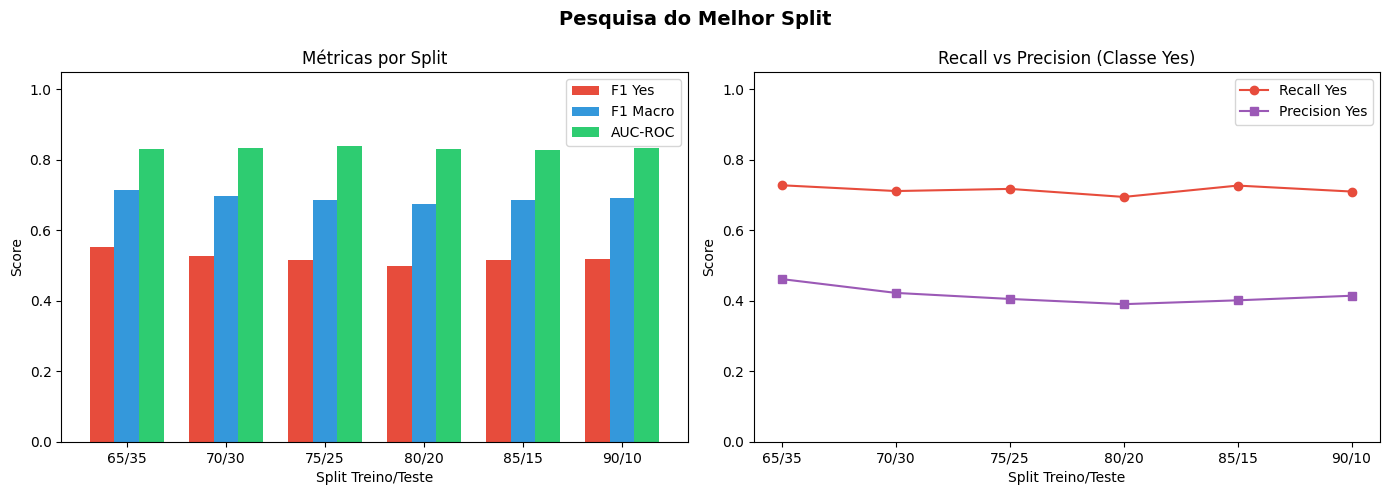

 Guardado: split_search.png


In [203]:
#  Visualização dos resultados de split 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 por split
ax = axes[0]
x = np.arange(len(split_labels))
w = 0.25
ax.bar(x - w, df_splits['F1 Yes'],   w, label='F1 Yes',   color='#e74c3c')
ax.bar(x,     df_splits['F1 Macro'], w, label='F1 Macro', color='#3498db')
ax.bar(x + w, df_splits['AUC-ROC'],  w, label='AUC-ROC',  color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(split_labels)
ax.set_xlabel('Split Treino/Teste')
ax.set_ylabel('Score')
ax.set_title('Métricas por Split')
ax.legend()
ax.set_ylim(0, 1.05)

# Recall vs Precision
ax2 = axes[1]
ax2.plot(split_labels, df_splits['Recall Yes'],    marker='o', label='Recall Yes',    color='#e74c3c')
ax2.plot(split_labels, df_splits['Precision Yes'], marker='s', label='Precision Yes', color='#9b59b6')
ax2.set_xlabel('Split Treino/Teste')
ax2.set_ylabel('Score')
ax2.set_title('Recall vs Precision (Classe Yes)')
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.suptitle('Pesquisa do Melhor Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('split_search.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: split_search.png')

## 4. Pesquisa do Melhor Normalizador

Usando o melhor split encontrado, testamos 4 estratégias de normalização:
- **StandardScaler** — média 0, desvio padrão 1 (sensível a outliers)
- **MinMaxScaler** — escala [0,1] (preserva distribuição)
- **RobustScaler** — baseado em mediana/IQR (robusto a outliers)
- **MaxAbsScaler** — escala [-1,1] sem centrar (preserva esparsidade)

In [204]:
# Split com o melhor valor encontrado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=BEST_TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
    'MaxAbsScaler':   MaxAbsScaler()
}

scaler_results = []

for name, scaler in scalers.items():
    pipeline_scaler = ImbPipeline([
        ('scaler', scaler.__class__()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

    scores = cross_validate(
        pipeline_scaler,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    scaler_results.append({
        'Normalizador': name,
        'F1 Yes': round(scores['test_f1_yes'].mean(), 4),
        'F1 Macro': round(scores['test_f1_macro'].mean(), 4),
        'Recall Yes': round(scores['test_recall_yes'].mean(), 4),
        'Precision Yes': round(scores['test_precision_yes'].mean(), 4),
        'AUC-ROC': round(scores['test_auc_roc'].mean(), 4)
    })

df_scalers = pd.DataFrame(scaler_results)
print('Comparação de Normalizadores com Validação Cruzada:')
print(df_scalers.to_string(index=False))

best_scaler_row = df_scalers.loc[df_scalers['F1 Yes'].idxmax()]
BEST_SCALER_NAME = best_scaler_row['Normalizador']
BEST_SCALER = scalers[BEST_SCALER_NAME]

print(f'Melhor normalizador: {BEST_SCALER_NAME} (F1 Yes CV = {best_scaler_row["F1 Yes"]})')


Comparação de Normalizadores com Validação Cruzada:
  Normalizador  F1 Yes  F1 Macro  Recall Yes  Precision Yes  AUC-ROC
StandardScaler  0.5530    0.7141      0.7279         0.4615   0.8304
  MinMaxScaler  0.5399    0.7056      0.7158         0.4477   0.8342
  RobustScaler  0.5282    0.6959      0.7218         0.4237   0.8276
  MaxAbsScaler  0.5222    0.6914      0.7091         0.4254   0.8325
Melhor normalizador: StandardScaler (F1 Yes CV = 0.553)


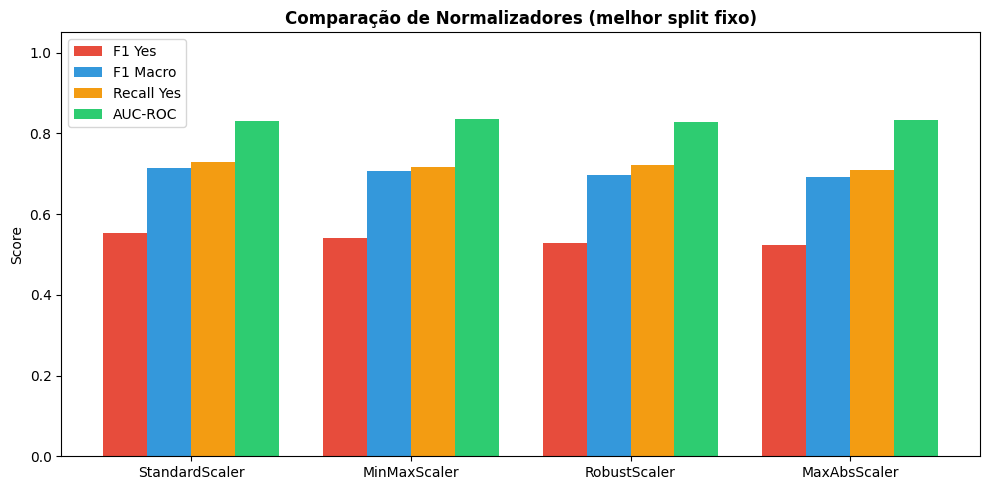

 Guardado: scaler_search.png


In [205]:
#  Visualização normalizadores 
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_scalers))
w = 0.2
ax.bar(x - 1.5*w, df_scalers['F1 Yes'],       w, label='F1 Yes',       color='#e74c3c')
ax.bar(x - 0.5*w, df_scalers['F1 Macro'],     w, label='F1 Macro',     color='#3498db')
ax.bar(x + 0.5*w, df_scalers['Recall Yes'],   w, label='Recall Yes',   color='#f39c12')
ax.bar(x + 1.5*w, df_scalers['AUC-ROC'],      w, label='AUC-ROC',      color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(df_scalers['Normalizador'])
ax.set_ylabel('Score')
ax.set_title('Comparação de Normalizadores (melhor split fixo)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('scaler_search.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: scaler_search.png')

## 5. Pesquisa da Melhor Variante de SMOTE

Usando o melhor split e melhor normalizador, testamos 7 estratégias de oversampling/resampling:

| Técnica | Descrição |
|---|---|
| **SMOTE** | Síntese de amostras por interpolação KNN clássica |
| **BorderlineSMOTE** | Foca nos exemplos na fronteira de decisão |
| **SVMSMOTE** | Usa SVM para identificar as amostras de suporte |
| **ADASYN** | Adapta a densidade — mais sintéticos nas zonas difíceis |
| **SMOTETomek** | SMOTE + remoção de pares Tomek (limpeza) |
| **SMOTEENN** | SMOTE + ENN (limpeza mais agressiva) |
| **Sem SMOTE** | Apenas `class_weight='balanced'` (baseline de comparação) |

In [206]:
# Dicionário com as variantes de resampling a comparar
# 'passthrough' = sem resampling
smote_variants = {
    'Sem SMOTE':       'passthrough',
    'SMOTE':           SMOTE(random_state=RANDOM_STATE),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=RANDOM_STATE),
    'SVMSMOTE':        SVMSMOTE(random_state=RANDOM_STATE),
    'ADASYN':          ADASYN(random_state=RANDOM_STATE),
    'SMOTETomek':      SMOTETomek(random_state=RANDOM_STATE),
    'SMOTEENN':        SMOTEENN(random_state=RANDOM_STATE)
}

smote_results = []

for name, sampler in smote_variants.items():
    sampler_step = 'passthrough' if sampler == 'passthrough' else sampler.__class__(random_state=RANDOM_STATE)

    pipeline_smote = ImbPipeline([
        ('scaler', scalers[BEST_SCALER_NAME].__class__()),
        ('smote', sampler_step),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ))
    ])

    scores = cross_validate(
        pipeline_smote,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    smote_results.append({
        'Técnica': name,
        'Amostras Treino': len(X_train),
        'F1 Yes': round(scores['test_f1_yes'].mean(), 4),
        'F1 Macro': round(scores['test_f1_macro'].mean(), 4),
        'Recall Yes': round(scores['test_recall_yes'].mean(), 4),
        'Precision Yes': round(scores['test_precision_yes'].mean(), 4),
        'AUC-ROC': round(scores['test_auc_roc'].mean(), 4)
    })

df_smote = pd.DataFrame(smote_results)
print('Comparação de Técnicas de Resampling com Validação Cruzada:')
print(df_smote.to_string(index=False))

best_smote_row = df_smote.loc[df_smote['F1 Yes'].idxmax()]
BEST_SMOTE_NAME = best_smote_row['Técnica']
BEST_SMOTE = smote_variants[BEST_SMOTE_NAME]

print(f'Melhor técnica: {BEST_SMOTE_NAME} (F1 Yes CV = {best_smote_row["F1 Yes"]})')


Comparação de Técnicas de Resampling com Validação Cruzada:
        Técnica  Amostras Treino  F1 Yes  F1 Macro  Recall Yes  Precision Yes  AUC-ROC
      Sem SMOTE              955  0.5154    0.6823      0.7224         0.4125   0.8296
          SMOTE              955  0.5530    0.7141      0.7279         0.4615   0.8304
BorderlineSMOTE              955  0.5557    0.7206      0.6958         0.4779   0.8362
       SVMSMOTE              955  0.5693    0.7323      0.6758         0.5107   0.8382
         ADASYN              955  0.5203    0.6882      0.7091         0.4228   0.8283
     SMOTETomek              955  0.5521    0.7133      0.7279         0.4604   0.8303
       SMOTEENN              955  0.4800    0.6440      0.7861         0.3517   0.8127
Melhor técnica: SVMSMOTE (F1 Yes CV = 0.5693)


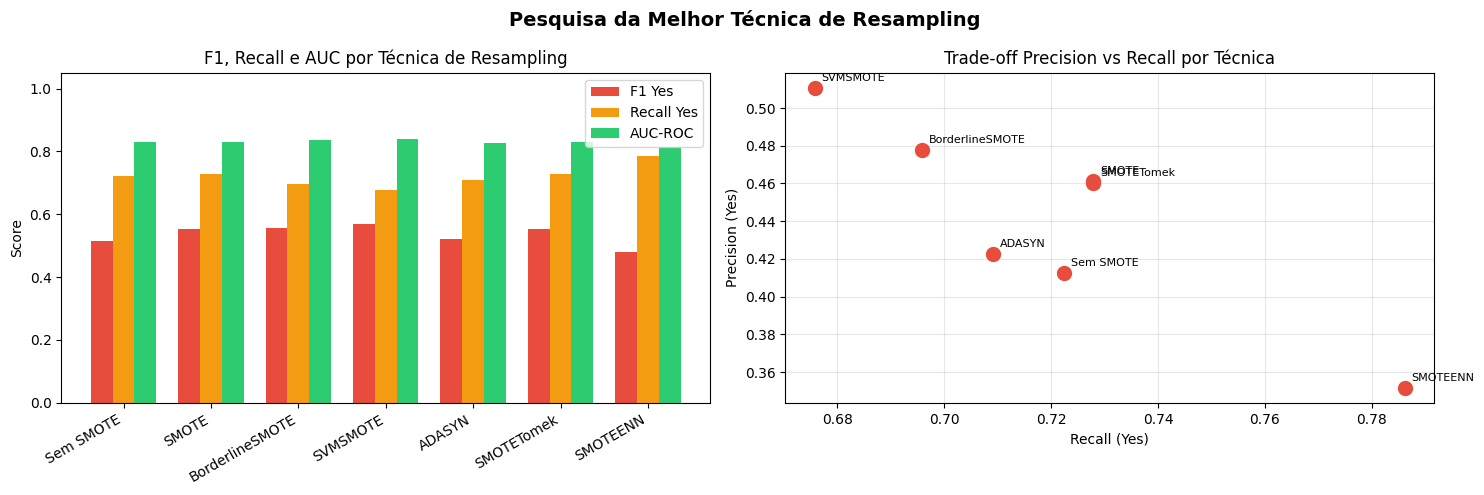

 Guardado: smote_search.png


In [207]:
#  Visualização SMOTE 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F1, Recall, AUC por técnica
ax = axes[0]
x = np.arange(len(df_smote))
w = 0.25
ax.bar(x - w, df_smote['F1 Yes'],     w, label='F1 Yes',     color='#e74c3c')
ax.bar(x,     df_smote['Recall Yes'], w, label='Recall Yes', color='#f39c12')
ax.bar(x + w, df_smote['AUC-ROC'],   w, label='AUC-ROC',    color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(df_smote['Técnica'], rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('F1, Recall e AUC por Técnica de Resampling')
ax.legend()
ax.set_ylim(0, 1.05)

# Precision vs Recall
ax2 = axes[1]
ax2.scatter(df_smote['Recall Yes'], df_smote['Precision Yes'],
            s=100, zorder=5, color='#e74c3c')
for _, row in df_smote.iterrows():
    ax2.annotate(row['Técnica'],
                 (row['Recall Yes'], row['Precision Yes']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax2.set_xlabel('Recall (Yes)')
ax2.set_ylabel('Precision (Yes)')
ax2.set_title('Trade-off Precision vs Recall por Técnica')
ax2.grid(True, alpha=0.3)

plt.suptitle('Pesquisa da Melhor Técnica de Resampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_search.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: smote_search.png')

## 6. Modelo Final Otimizado

Com a combinação ótima encontrada (melhor split + melhor normalizador + melhor SMOTE), aplicamos:
- **GridSearchCV** para afinar os hiperparâmetros da Regressão Logística
- **StratifiedKFold (k=15)** para garantir robustez dos resultados

In [208]:
# Resume a configuração ótima encontrada nas 3 pesquisas anteriores
print("\n=== Melhor configuração ===")
print(f"Split        : {BEST_SPLIT_LABEL}")
print(f"Normalização : {BEST_SCALER_NAME}")
print(f"Resampling   : {BEST_SMOTE_NAME}")


=== Melhor configuração ===
Split        : 65/35
Normalização : StandardScaler
Resampling   : SVMSMOTE


In [209]:
# Preparação final dos dados

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y, test_size=BEST_TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

sampler_final = (
    'passthrough'
    if BEST_SMOTE_NAME == 'Sem SMOTE'
    else smote_variants[BEST_SMOTE_NAME].__class__(random_state=RANDOM_STATE)
)

pipeline_final = ImbPipeline([
    ('scaler', scalers[BEST_SCALER_NAME].__class__()),
    ('smote', sampler_final),
    ('model', LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))
])

print(f'Treino final: {len(X_train_f)} amostras')
print(f'Teste final:  {len(X_test_f)} amostras')
print(f'  Yes treino (1): {y_train_f.sum()} | No treino (0): {(y_train_f == 0).sum()}')
print(f'  Yes teste  (1): {y_test_f.sum()} | No teste  (0): {(y_test_f == 0).sum()}')


Treino final: 955 amostras
Teste final:  515 amostras
  Yes treino (1): 154 | No treino (0): 801
  Yes teste  (1): 83 | No teste  (0): 432


In [210]:
# GridSearchCV

param_grid = [
    {
        'model__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        'model__penalty': ['l1'],
        'model__solver': ['saga'],
        'model__class_weight': ['balanced']
    },
    {
        'model__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        'model__penalty': ['l2'],
        'model__solver': ['saga'],
        'model__class_weight': ['balanced']
    },
    {
        'model__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        'model__penalty': ['elasticnet'],
        'model__solver': ['saga'],
        'model__l1_ratio': [0.1, 0.5, 0.9],
        'model__class_weight': ['balanced']
    }
]

cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline_final,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_f, y_train_f)

print(f'ridSearchCV concluído')
print(f'   Melhores parâmetros: {grid_search.best_params_}')
print(f'   Melhor F1 (CV treino): {grid_search.best_score_:.4f}')


Fitting 15 folds for each of 45 candidates, totalling 675 fits
ridSearchCV concluído
   Melhores parâmetros: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'saga'}
   Melhor F1 (CV treino): 0.5800


In [211]:
# Cross-Validation no conjunto de treino com modelo final

best_model = grid_search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X_train_f,
    y_train_f,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print(f'Cross-Validation — F1 Yes:')
print(f'   Scores por fold: {[round(s,4) for s in cv_scores]}')
print(f'   Média:           {cv_scores.mean():.4f}')
print(f'   Desvio Padrão:   {cv_scores.std():.4f}')

# Avaliação inicial no teste com threshold padrão de 0.5
y_pred_f = best_model.predict(X_test_f)
y_prob_f = best_model.predict_proba(X_test_f)[:, 1]

print(f'Avaliação no Conjunto de Teste — threshold 0.5:')
print(classification_report(y_test_f, y_pred_f, target_names=['No (0)', 'Yes (1)']))

import warnings
warnings.filterwarnings('ignore', category=UserWarning)


Cross-Validation — F1 Yes:
   Scores por fold: [np.float64(0.4615), np.float64(0.56), np.float64(0.6087), np.float64(0.75), np.float64(0.6316), np.float64(0.6), np.float64(0.5185), np.float64(0.56), np.float64(0.4615), np.float64(0.5806), np.float64(0.5882), np.float64(0.6923), np.float64(0.6154), np.float64(0.5), np.float64(0.5714)]
   Média:           0.5800
   Desvio Padrão:   0.0756
Avaliação no Conjunto de Teste — threshold 0.5:
              precision    recall  f1-score   support

      No (0)       0.92      0.84      0.88       432
     Yes (1)       0.43      0.61      0.50        83

    accuracy                           0.81       515
   macro avg       0.67      0.73      0.69       515
weighted avg       0.84      0.81      0.82       515



## 7. Avaliação Final do Modelo

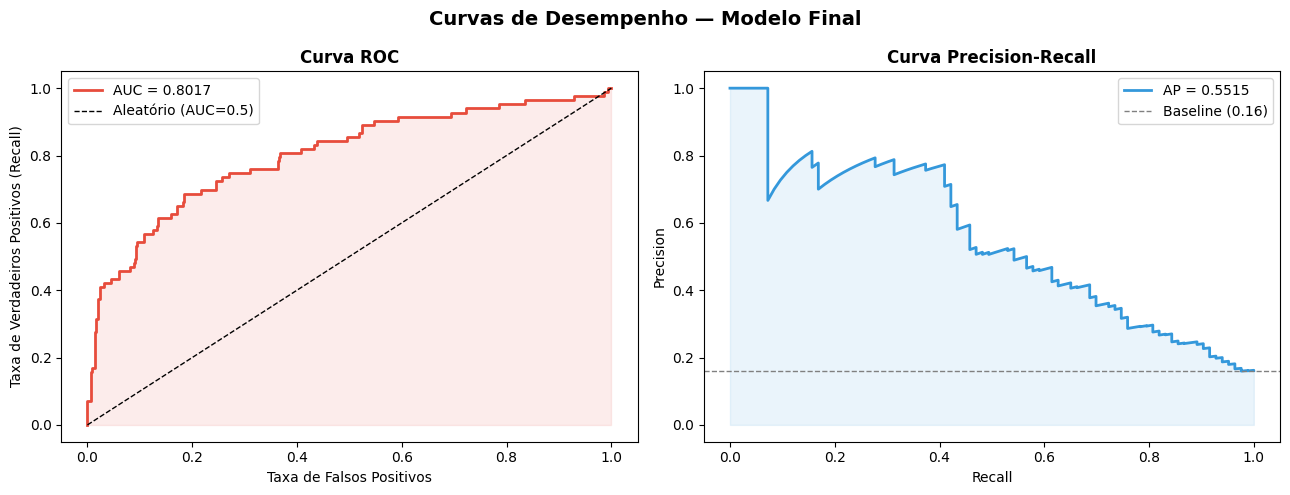

 Guardado: roc_pr_curves_final.png


In [212]:
#  Curva ROC 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
# Calcula os pontos da curva ROC: taxa de falsos positivos vs taxa de verdadeiros positivos
fpr, tpr, _ = roc_curve(y_test_f, y_prob_f)
# AUC = área sob a curva ROC; 1.0 = perfeito, 0.5 = aleatório
auc_val = roc_auc_score(y_test_f, y_prob_f)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Aleatório (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend()

# Precision-Recall
# Curva Precision-Recall: especialmente útil para datasets desequilibrados
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test_f, y_prob_f)
# AP (Average Precision) = área sob a curva PR; equivalente ao AUC mas para PR
ap = average_precision_score(y_test_f, y_prob_f)
axes[1].plot(recall_curve, precision_curve, color='#3498db', lw=2, label=f'AP = {ap:.4f}')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color='#3498db')
axes[1].axhline(y_test_f.mean(), color='gray', linestyle='--', lw=1, label=f'Baseline ({y_test_f.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend()

plt.suptitle('Curvas de Desempenho — Modelo Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: roc_pr_curves_final.png')

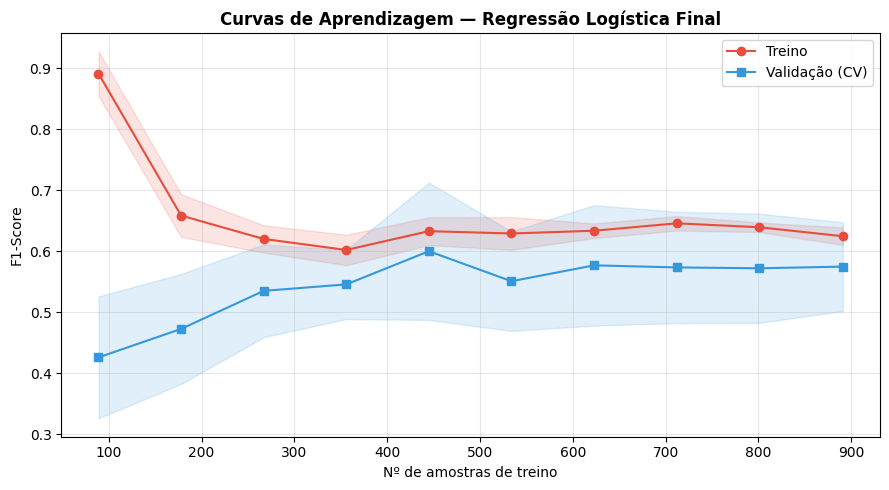

 Guardado: learning_curves_final.png


In [213]:
# Curvas de Aprendizagem

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_f,
    y_train_f,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Treino')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
plt.plot(train_sizes, val_mean, 's-', color='#3498db', label='Validação (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#3498db')
plt.xlabel('Nº de amostras de treino')
plt.ylabel('F1-Score')
plt.title('Curvas de Aprendizagem — Regressão Logística Final', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Guardado: learning_curves_final.png')


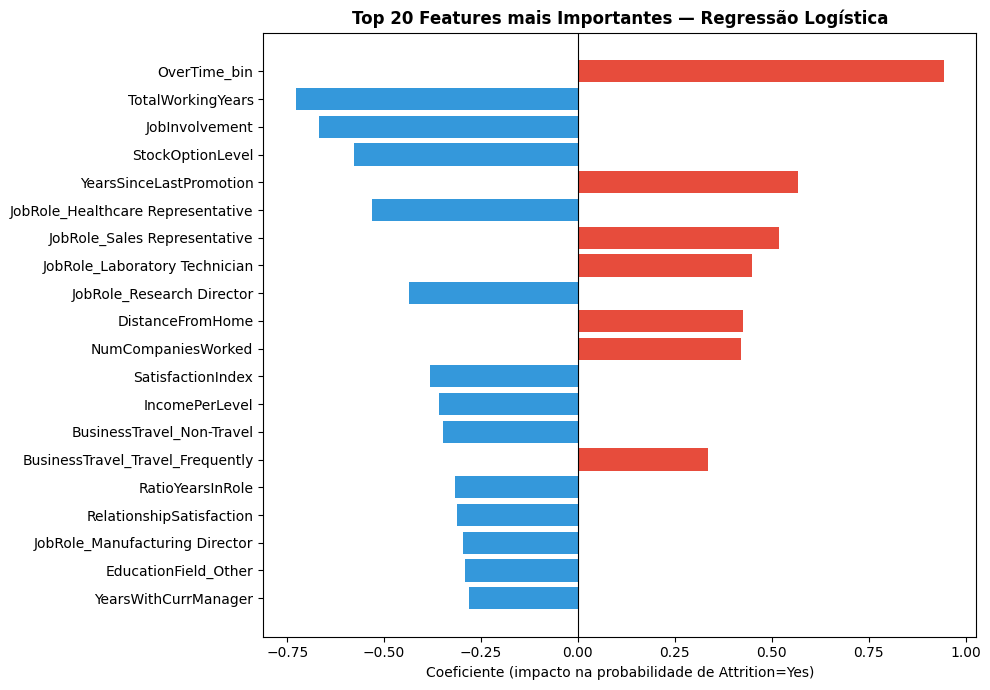

Top 10 features:
                          Feature  Coeficiente
                     OverTime_bin     0.944134
                TotalWorkingYears    -0.728135
                   JobInvolvement    -0.667947
                 StockOptionLevel    -0.577758
          YearsSinceLastPromotion     0.568629
JobRole_Healthcare Representative    -0.532131
     JobRole_Sales Representative     0.517500
    JobRole_Laboratory Technician     0.450194
        JobRole_Research Director    -0.434513
                 DistanceFromHome     0.425887
 Guardado: feature_importance_final.png


In [214]:
# Feature Importance (Coeficientes)

modelo_lr = best_model.named_steps['model']

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_lr.coef_[0],
    'Abs': np.abs(modelo_lr.coef_[0])
}).sort_values('Abs', ascending=False)

top_n = 20
top_coef = coef_df.head(top_n)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_coef['Coeficiente']]
plt.barh(top_coef['Feature'][::-1], top_coef['Coeficiente'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (impacto na probabilidade de Attrition=Yes)')
plt.title(f'Top {top_n} Features mais Importantes — Regressão Logística', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top 10 features:')
print(coef_df[['Feature', 'Coeficiente']].head(10).to_string(index=False))
print(' Guardado: feature_importance_final.png')


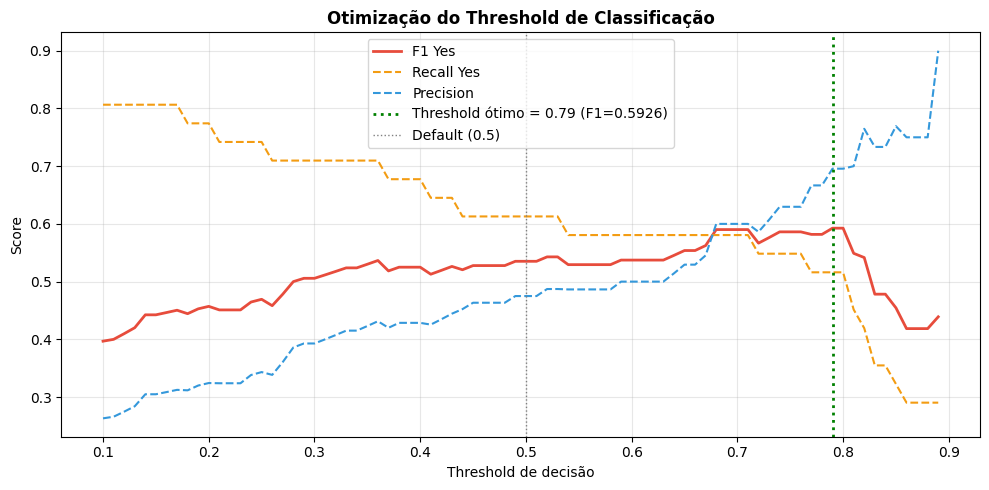

Threshold ótimo: 0.79
   F1 Yes com threshold padrão (0.5): 0.5050
   F1 Yes com threshold ótimo (0.79): 0.5147
 Guardado: threshold_optimization.png


In [215]:
# Otimização de Threshold

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_f,
    y_train_f,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_f
)

threshold_model = clone(grid_search.best_estimator_)
threshold_model.fit(X_train_sub, y_train_sub)

y_prob_val = threshold_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores_thresh = []
recall_thresh = []
prec_thresh = []

for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    f1_scores_thresh.append(f1_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    recall_thresh.append(recall_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    prec_thresh.append(precision_score(y_val, y_pred_t, pos_label=1, zero_division=0))

best_thresh_idx = np.argmax(f1_scores_thresh)
best_threshold = thresholds[best_thresh_idx]
best_f1_thresh = f1_scores_thresh[best_thresh_idx]

# Reajusta o modelo final em todo o conjunto de treino após escolher o threshold
best_model = clone(grid_search.best_estimator_)
best_model.fit(X_train_f, y_train_f)

y_prob_f = best_model.predict_proba(X_test_f)[:, 1]
y_pred_f = best_model.predict(X_test_f)
y_pred_opt = (y_prob_f >= best_threshold).astype(int)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores_thresh, label='F1 Yes', color='#e74c3c', lw=2)
plt.plot(thresholds, recall_thresh, label='Recall Yes', color='#f39c12', lw=1.5, linestyle='--')
plt.plot(thresholds, prec_thresh, label='Precision', color='#3498db', lw=1.5, linestyle='--')
plt.axvline(best_threshold, color='green', linestyle=':', lw=2,
            label=f'Threshold ótimo = {best_threshold:.2f} (F1={best_f1_thresh:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', lw=1, label='Default (0.5)')
plt.xlabel('Threshold de decisão')
plt.ylabel('Score')
plt.title('Otimização do Threshold de Classificação', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold ótimo: {best_threshold:.2f}')
print(f'   F1 Yes com threshold padrão (0.5): {f1_score(y_test_f, y_pred_f, pos_label=1):.4f}')
print(f'   F1 Yes com threshold ótimo ({best_threshold:.2f}): {f1_score(y_test_f, y_pred_opt, pos_label=1):.4f}')
print(' Guardado: threshold_optimization.png')


## 7.2 Comparação Treino vs Teste

Análise do comportamento do modelo nos dados de treino (Cross-Validation 15-Fold sobre dados SMOTE) versus o conjunto de teste real (distribuição original, 85/15).

In [216]:
# MÉTRICAS NO TREINO

# Previsões no conjunto de treino apenas para análise descritiva
# O F1 médio da validação cruzada continua a ser a métrica mais fiável para treino
y_proba_train_f = best_model.predict_proba(X_train_f)[:, 1]
y_pred_train_f = (y_proba_train_f >= best_threshold).astype(int)

print('===== MÉTRICAS — TREINO =====')
print(f'  F1-Score (CV médio): {cv_scores.mean():.4f}')
print(f'  Desvio Padrão:       {cv_scores.std():.4f}')
print(f'  Scores por fold:     {[round(s,4) for s in cv_scores]}')
print()
print(classification_report(y_train_f, y_pred_train_f, target_names=['Permaneceu (No)', 'Saiu (Yes)']))

===== MÉTRICAS — TREINO =====
  F1-Score (CV médio): 0.5800
  Desvio Padrão:       0.0756
  Scores por fold:     [np.float64(0.4615), np.float64(0.56), np.float64(0.6087), np.float64(0.75), np.float64(0.6316), np.float64(0.6), np.float64(0.5185), np.float64(0.56), np.float64(0.4615), np.float64(0.5806), np.float64(0.5882), np.float64(0.6923), np.float64(0.6154), np.float64(0.5), np.float64(0.5714)]

                 precision    recall  f1-score   support

Permaneceu (No)       0.91      0.97      0.94       801
     Saiu (Yes)       0.77      0.49      0.60       154

       accuracy                           0.89       955
      macro avg       0.84      0.73      0.77       955
   weighted avg       0.89      0.89      0.88       955



In [217]:
# MÉTRICAS NO TESTE

y_pred_test_f = y_pred_opt
y_proba_test_f = y_prob_f

print('===== MÉTRICAS — TESTE =====')
print(f'  Threshold:   {best_threshold:.2f}')
print(f'  F1-Score:    {f1_score(y_test_f, y_pred_test_f):.4f}')
print(f'  Precision:   {precision_score(y_test_f, y_pred_test_f):.4f}')
print(f'  Recall:      {recall_score(y_test_f, y_pred_test_f):.4f}')
print(f'  AUC-ROC:     {roc_auc_score(y_test_f, y_proba_test_f):.4f}')
print()
print(classification_report(y_test_f, y_pred_test_f, target_names=['Permaneceu (No)', 'Saiu (Yes)']))


===== MÉTRICAS — TESTE =====
  Threshold:   0.79
  F1-Score:    0.5147
  Precision:   0.6604
  Recall:      0.4217
  AUC-ROC:     0.8017

                 precision    recall  f1-score   support

Permaneceu (No)       0.90      0.96      0.93       432
     Saiu (Yes)       0.66      0.42      0.51        83

       accuracy                           0.87       515
      macro avg       0.78      0.69      0.72       515
   weighted avg       0.86      0.87      0.86       515



In [218]:
# TABELA COMPARATIVA TREINO vs TESTE

resultados_lr_final = pd.DataFrame({
    'Conjunto':  ['Treino', 'Teste'],
    'F1-Score':  [round(f1_score(y_train_f, y_pred_train_f), 4), round(f1_score(y_test_f, y_pred_test_f), 4)],
    'Precision': [round(precision_score(y_train_f, y_pred_train_f), 4), round(precision_score(y_test_f, y_pred_test_f), 4)],
    'Recall':    [round(recall_score(y_train_f, y_pred_train_f), 4), round(recall_score(y_test_f, y_pred_test_f), 4)],
    'AUC-ROC':   [round(roc_auc_score(y_train_f, y_proba_train_f), 4), round(roc_auc_score(y_test_f, y_proba_test_f), 4)],
})

print('===== TABELA COMPARATIVA TREINO vs TESTE =====')
display(resultados_lr_final)

diff = cv_scores.mean() - f1_score(y_test_f, y_pred_test_f)
print(f'Diferença F1 CV treino - teste: {diff:.4f}')
if diff > 0.10:
    print('  --> Possível sinal de overfitting: o desempenho médio em CV é superior ao desempenho no teste.')
else:
    print('  --> Sem sinais evidentes de overfitting.')


===== TABELA COMPARATIVA TREINO vs TESTE =====


,Conjunto,F1-Score,Precision,Recall,AUC-ROC
0,Treino,0.5976,0.7732,0.4870,0.8860
1,Teste,0.5147,0.6604,0.4217,0.8017


Diferença F1 CV treino - teste: 0.0653
  --> Sem sinais evidentes de overfitting.


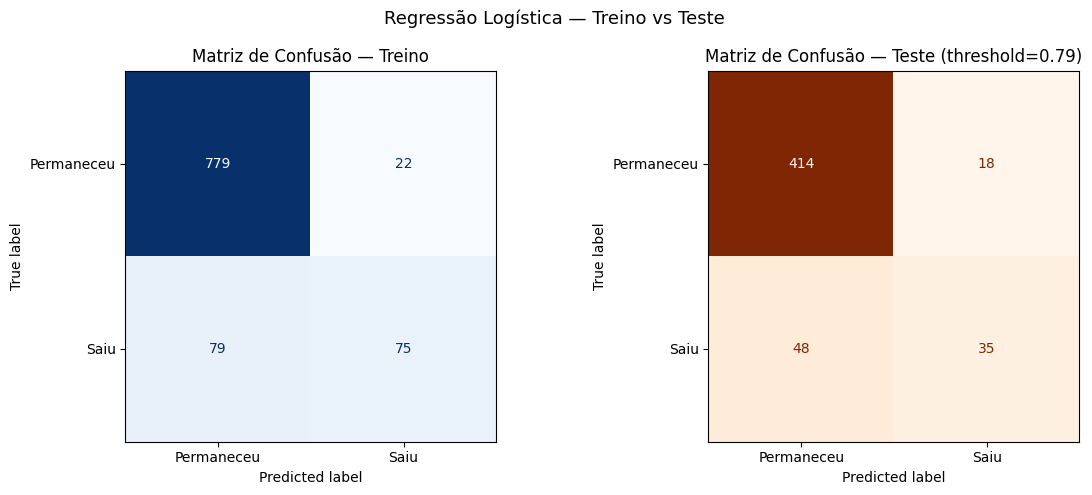

Guardado: confusion_matrix_treino_vs_teste.png


In [219]:
# MATRIZES DE CONFUSÃO — TREINO vs TESTE

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_f, y_pred_train_f),
    display_labels=['Permaneceu', 'Saiu']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Treino')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_f, y_pred_test_f),
    display_labels=['Permaneceu', 'Saiu']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Matriz de Confusão — Teste (threshold={best_threshold:.2f})')

fig.suptitle('Regressão Logística — Treino vs Teste', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_treino_vs_teste.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: confusion_matrix_treino_vs_teste.png')


## 8. Resumo Final e Conclusão

In [220]:
# TABELA DE PROGRESSÃO DO MODELO

y_pred_opt = (y_prob_f >= best_threshold).astype(int)

summary = pd.DataFrame([
    {
        'Modelo': 'Baseline (Log. Reg. default)',
        'Split': '80/20', 'Normalizador': 'StandardScaler',
        'Resampling': 'SMOTE base', 'Threshold': 0.5,
        'F1 Yes': df_splits.loc[df_splits['Split']=='80/20','F1 Yes'].values[0],
        'AUC-ROC': df_splits.loc[df_splits['Split']=='80/20','AUC-ROC'].values[0]
    },
    {
        'Modelo': f'Melhor Split ({BEST_SPLIT_LABEL})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': 'StandardScaler',
        'Resampling': 'SMOTE base', 'Threshold': 0.5,
        'F1 Yes': best_split_row['F1 Yes'],
        'AUC-ROC': best_split_row['AUC-ROC']
    },
    {
        'Modelo': f'+ Melhor Normalizador ({BEST_SCALER_NAME})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': 'SMOTE base', 'Threshold': 0.5,
        'F1 Yes': best_scaler_row['F1 Yes'],
        'AUC-ROC': best_scaler_row['AUC-ROC']
    },
    {
        'Modelo': f'+ Melhor SMOTE ({BEST_SMOTE_NAME})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': BEST_SMOTE_NAME, 'Threshold': 0.5,
        'F1 Yes': best_smote_row['F1 Yes'],
        'AUC-ROC': best_smote_row['AUC-ROC']
    },
    {
        'Modelo': '+ GridSearchCV (threshold 0.5)',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': BEST_SMOTE_NAME, 'Threshold': 0.5,
        'F1 Yes': round(f1_score(y_test_f, y_pred_f, pos_label=1), 4),
        'AUC-ROC': round(roc_auc_score(y_test_f, y_prob_f), 4)
    },
    {
        'Modelo': f'MODELO FINAL (threshold={best_threshold:.2f})',
        'Split': BEST_SPLIT_LABEL, 'Normalizador': BEST_SCALER_NAME,
        'Resampling': BEST_SMOTE_NAME, 'Threshold': best_threshold,
        'F1 Yes': round(f1_score(y_test_f, y_pred_opt, pos_label=1), 4),
        'AUC-ROC': round(roc_auc_score(y_test_f, y_prob_f), 4)
    },
])

print('' + '═'*100)
print('  TABELA COMPARATIVA COMPLETA — PROGRESSÃO DO MODELO')
print('═'*100)
print(summary.to_string(index=False))
print('═'*100)


════════════════════════════════════════════════════════════════════════════════════════════════════
  TABELA COMPARATIVA COMPLETA — PROGRESSÃO DO MODELO
════════════════════════════════════════════════════════════════════════════════════════════════════
                                Modelo Split   Normalizador Resampling  Threshold  F1 Yes  AUC-ROC
          Baseline (Log. Reg. default) 80/20 StandardScaler SMOTE base       0.50  0.4978   0.8323
                  Melhor Split (65/35) 65/35 StandardScaler SMOTE base       0.50  0.5530   0.8304
+ Melhor Normalizador (StandardScaler) 65/35 StandardScaler SMOTE base       0.50  0.5530   0.8304
             + Melhor SMOTE (SVMSMOTE) 65/35 StandardScaler   SVMSMOTE       0.50  0.5693   0.8382
        + GridSearchCV (threshold 0.5) 65/35 StandardScaler   SVMSMOTE       0.50  0.5050   0.8017
         MODELO FINAL (threshold=0.79) 65/35 StandardScaler   SVMSMOTE       0.79  0.5147   0.8017
════════════════════════════════════════════════════

In [221]:
# Relatório completo do modelo final com threshold otimizado
print("\n=== Relatório final ===")
print("Threshold otimizado aplicado\n")

print(classification_report(
    y_test_f, 
    y_pred_opt, 
    target_names=['No (0)', 'Yes (1)']
))

# Mostra os hiperparâmetros escolhidos pelo GridSearchCV
print("Parâmetros do modelo:")
print(grid_search.best_params_)


=== Relatório final ===
Threshold otimizado aplicado

              precision    recall  f1-score   support

      No (0)       0.90      0.96      0.93       432
     Yes (1)       0.66      0.42      0.51        83

    accuracy                           0.87       515
   macro avg       0.78      0.69      0.72       515
weighted avg       0.86      0.87      0.86       515

Parâmetros do modelo:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'saga'}


In [222]:
# EXPRESSÃO DO MODELO FINAL

modelo_lr = best_model.named_steps['model']

coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
}).sort_values('Coeficiente', ascending=False)

interceto = modelo_lr.intercept_[0]

print('Expressão do modelo:')
print(f'logit(p) = {interceto:.6f}', end=' ')

for _, row in coeficientes.iterrows():
    sinal = '+' if row['Coeficiente'] >= 0 else '-'
    print(f'{sinal} {abs(row["Coeficiente"]):.6f}*{row["Feature"]}', end=' ')

print('Probabilidade:')
print('p = 1 / (1 + exp(-logit(p)))')

print('Threshold final:')
print(f'Se p >= {best_threshold:.2f}, então prevê Attrition = Yes')
print(f'Se p < {best_threshold:.2f}, então prevê Attrition = No')


Expressão do modelo:
logit(p) = -1.871048 + 0.944134*OverTime_bin + 0.568629*YearsSinceLastPromotion + 0.517500*JobRole_Sales Representative + 0.450194*JobRole_Laboratory Technician + 0.425887*DistanceFromHome + 0.419721*NumCompaniesWorked + 0.336807*BusinessTravel_Travel_Frequently + 0.278695*MonthlyIncome + 0.229722*Gender_bin + 0.226127*MaritalStatus_Single + 0.209599*JobRole_Sales Executive + 0.182942*JobRole_Human Resources + 0.161853*EducationField_Human Resources + 0.159507*EducationField_Marketing + 0.124422*EducationField_Technical Degree + 0.108747*PercentSalaryHike + 0.102351*MonthlyRate + 0.050106*Department_Research & Development + 0.020261*CareerStagnation + 0.018474*JobLevel + 0.014983*EducationField_Medical + 0.001405*Department_Sales + 0.000147*JobRole_Manager - 0.002178*Education - 0.042823*BusinessTravel_Travel_Rarely - 0.055297*YearsInCurrentRole - 0.101136*MaritalStatus_Married - 0.106988*EducationField_Life Sciences - 0.114163*YearsAtCompany - 0.126001*Department_

## Conclusão

O modelo final de **Regressão Logística** foi construído em três etapas de pesquisa sistemática:

1. **Pesquisa de Split** — testámos 6 proporções (65/35 a 90/10). O split que maximizou o F1 na classe `Yes` foi selecionado para todas as fases seguintes.

2. **Pesquisa de Normalizador** — comparámos StandardScaler, MinMaxScaler, RobustScaler e MaxAbsScaler. A regressão logística é sensível à escala das variáveis, pelo que esta escolha tem impacto direto no desempenho.

3. **Pesquisa de Resampling** — testámos 7 técnicas (SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN, SMOTETomek, SMOTEENN e sem resampling). As variantes que focam nas fronteiras de decisão ou que combinam oversampling com limpeza tendem a reduzir o ruído sintético.

4. **Otimização de Hiperparâmetros** — GridSearchCV com 5-Fold Stratified CV otimizado para F1, explorando penalizações L1, L2 e ElasticNet.

5. **Threshold** — o threshold padrão (0.5) foi substituído pelo threshold ótimo que maximiza o F1 na classe minoritária, equilibrando Precision e Recall.

---
*Última atualização: 15/05/2026 | - Luís Figueira*